#**Taller Parcial**

Le han solicitado que ayude a las autoridades locales a hacer la planeación de la atención y prevención de los accidentes de tránsito en la ciudad de Medellin, para lo cual le han suministrado los datos de los accidentes de tránsito que se han presentado durante el año 2018.

Se espera que informe:
1. Dónde ubicar:
*   los agentes de tránsito
*   las ambulancias
2. Los horarios y el personal qué debe estar disponible para atender los eventos. Teniendo en cuenta en qué horarios, días y fechas particulares se presentan mayor accidentalidad y de qué tipo.
3. Recomendaciones para prevenir los accidentes de tránsito.


**Se debe entregar el reporte hasta el lunes 17 de marzo, incluyendo el código y todos los análisis correspondientes.**

In [81]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [82]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, KMeans, DBSCAN

from scipy.cluster.hierarchy import dendrogram, linkage

In [83]:
path= "/content/drive/MyDrive/Colab aprendizaje no supervisado/Taller parcial/Accidentalidad_georreferenciada_2018.xlsx" # Colocar la ubicación del archivo
data= pd.read_excel(path) # Creamos el dataframe con los datos
data.head()

,X,Y,OBJECTID,RADICADO,FECHA,HORA,DIA,PERIODO,CLASE,DIRECCION,...,BARRIO,COMUNA,DISENO,DIA_NOMBRE,MES,MES_NOMBRE,X_MAGNAMED,Y_MAGNAMED,LONGITUD,LATITUD
0,-75.565634,6.299676,549556,1611786.0,2018/01/02 00:00:00+00,03:18:00,2,2018,Atropello,CR 64 C CL 103 GG,...,Girardot,Castilla,Tramo de via,MARTES,1,NaN,835295.93,1188611.46,-75.565634,6.299676
1,-75.703816,6.221806,549557,1611722.0,2018/01/02 00:00:00+00,03:35:00,2,2018,Choque,CR 63 CL 123,...,NaN,NaN,Lote o Predio,MARTES,1,NaN,820000.00,1180000.00,-75.703816,6.221806
2,-75.591074,6.268543,549558,1611859.0,2018/01/02 00:00:00+00,05:10:00,2,2018,Choque,CR 75 CL 59,...,San Germán,Robledo,Tramo de via,MARTES,1,NaN,832480.16,1185167.89,-75.591074,6.268543
3,-75.569627,6.219092,549559,1611705.0,2018/01/02 00:00:00+00,05:26:00,2,2018,Otro,CR 43 A CL 17,...,Castropol,El Poblado,Lote o Predio,MARTES,1,NaN,834853.96,1179697.78,-75.569627,6.219092
4,-75.575473,6.240001,549560,1611750.0,2018/01/02 00:00:00+00,05:45:00,2,2018,Choque,CR 55 CL 37,...,Calle Nueva,La Candelaria,Tramo de via,MARTES,1,NaN,834206.83,1182010.64,-75.575473,6.240001


# Limpieza de datos

In [84]:
# Eliminar la columna 'CBML'
data = data.drop(columns=['X','Y','RADICADO','PERIODO','DIRECCION_ENC','MES_NOMBRE','X_MAGNAMED','Y_MAGNAMED','CBML','TIPO_GEOCOD'])
data.head()

,OBJECTID,FECHA,HORA,DIA,CLASE,DIRECCION,GRAVEDAD,BARRIO,COMUNA,DISENO,DIA_NOMBRE,MES,LONGITUD,LATITUD
0,549556,2018/01/02 00:00:00+00,03:18:00,2,Atropello,CR 64 C CL 103 GG,MUERTO,Girardot,Castilla,Tramo de via,MARTES,1,-75.565634,6.299676
1,549557,2018/01/02 00:00:00+00,03:35:00,2,Choque,CR 63 CL 123,HERIDO,NaN,NaN,Lote o Predio,MARTES,1,-75.703816,6.221806
2,549558,2018/01/02 00:00:00+00,05:10:00,2,Choque,CR 75 CL 59,SOLO DAÑOS,San Germán,Robledo,Tramo de via,MARTES,1,-75.591074,6.268543
3,549559,2018/01/02 00:00:00+00,05:26:00,2,Otro,CR 43 A CL 17,HERIDO,Castropol,El Poblado,Lote o Predio,MARTES,1,-75.569627,6.219092
4,549560,2018/01/02 00:00:00+00,05:45:00,2,Choque,CR 55 CL 37,HERIDO,Calle Nueva,La Candelaria,Tramo de via,MARTES,1,-75.575473,6.240001


In [85]:
data.shape

(43455, 14)

In [86]:
# Creamos un dataframe en el cual se eliminan los outliers
threshold = 3

# Calculate z-scores for 'LONGITUD' and 'LATITUD'
data['z_X'] = (data['LONGITUD'] - data['LONGITUD'].mean()) / data['LONGITUD'].std()
data['z_Y'] = (data['LATITUD'] - data['LATITUD'].mean()) / data['LATITUD'].std()

# Filter data based on z-scores
data_clean = data[(data['z_X'].abs() < threshold) & (data['z_Y'].abs() < threshold)]

In [87]:
data_clean.shape

(40347, 16)

Se identificaron los datos atípicos en las variables latitud y longitud

In [88]:
# Convert 'fecha' column to datetime objects if it's not already
data_clean['FECHA'] = pd.to_datetime(data_clean['FECHA'])

# Format the dates as 'day/month/year'
data_clean['FECHA'] = data_clean['FECHA'].dt.strftime('%d/%m/%Y')


<ipython-input-88-f8632a7d4c06>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean['FECHA'] = pd.to_datetime(data_clean['FECHA'])
<ipython-input-88-f8632a7d4c06>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean['FECHA'] = data_clean['FECHA'].dt.strftime('%d/%m/%Y')


In [89]:
data_clean.head()

,OBJECTID,FECHA,HORA,DIA,CLASE,DIRECCION,GRAVEDAD,BARRIO,COMUNA,DISENO,DIA_NOMBRE,MES,LONGITUD,LATITUD,z_X,z_Y
0,549556,02/01/2018,03:18:00,2,Atropello,CR 64 C CL 103 GG,MUERTO,Girardot,Castilla,Tramo de via,MARTES,1,-75.565634,6.299676,0.548430,1.784761
2,549558,02/01/2018,05:10:00,2,Choque,CR 75 CL 59,SOLO DAÑOS,San Germán,Robledo,Tramo de via,MARTES,1,-75.591074,6.268543,-0.131660,0.696775
3,549559,02/01/2018,05:26:00,2,Otro,CR 43 A CL 17,HERIDO,Castropol,El Poblado,Lote o Predio,MARTES,1,-75.569627,6.219092,0.441694,-1.031431
4,549560,02/01/2018,05:45:00,2,Choque,CR 55 CL 37,HERIDO,Calle Nueva,La Candelaria,Tramo de via,MARTES,1,-75.575473,6.240001,0.285397,-0.300708
5,549561,02/01/2018,06:00:00,2,Otro,CR 64 C CL 104,HERIDO,Las Brisas,Castilla,Tramo de via,MARTES,1,-75.563815,6.301392,0.597079,1.844745


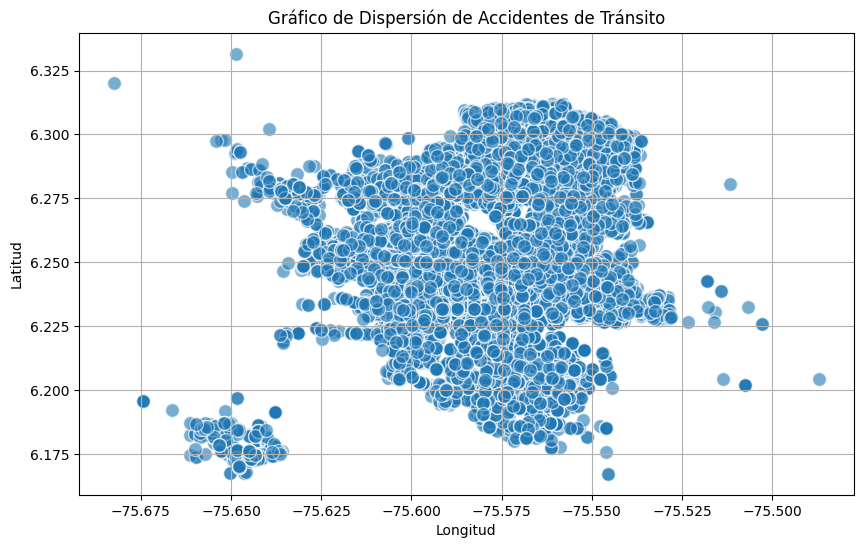

In [90]:
# Crear el gráfico de dispersión
plt.figure(figsize=(10, 6))
plt.scatter(data_clean['LONGITUD'], data_clean['LATITUD'], alpha=0.6, edgecolors='w', s=100)

# Personalizar el gráfico
plt.title('Gráfico de Dispersión de Accidentes de Tránsito')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(True)

# Mostrar el gráfico
plt.show()

In [91]:
data_clean.isna().sum()

,0
OBJECTID,0
FECHA,0
HORA,215
DIA,0
CLASE,0
DIRECCION,0
GRAVEDAD,0
BARRIO,63
COMUNA,43
DISENO,216


In [92]:
# Create a copy to avoid modifying the original DataFrame
data_clean = data_clean.copy()

# Group data by 'BARRIO' and calculate the mean latitude and longitude for each barrio
barrio_coords = data_clean.groupby('BARRIO')[['LATITUD', 'LONGITUD']].mean()

# Function to impute 'BARRIO' based on latitude and longitude
def impute_barrio(row):
    if pd.isnull(row['BARRIO']):
        # Find the nearest barrio based on Euclidean distance
        distances = np.sqrt((barrio_coords['LATITUD'] - row['LATITUD'])**2 + (barrio_coords['LONGITUD'] - row['LONGITUD'])**2)
        nearest_barrio = distances.idxmin()
        return nearest_barrio
    else:
        return row['BARRIO']

# Apply the imputation function to the DataFrame
data_clean['BARRIO'] = data_clean.apply(impute_barrio, axis=1)

# Display the first few rows to see the imputed values
print(data_clean.head())

# Check for missing values in 'BARRIO' column after imputation
print(data_clean.isna().sum())


   OBJECTID       FECHA      HORA  DIA      CLASE          DIRECCION  \
0    549556  02/01/2018  03:18:00    2  Atropello  CR 64 C CL 103 GG   
2    549558  02/01/2018  05:10:00    2     Choque        CR 75 CL 59   
3    549559  02/01/2018  05:26:00    2       Otro      CR 43 A CL 17   
4    549560  02/01/2018  05:45:00    2     Choque        CR 55 CL 37   
5    549561  02/01/2018  06:00:00    2       Otro     CR 64 C CL 104   

     GRAVEDAD       BARRIO         COMUNA         DISENO DIA_NOMBRE  MES  \
0      MUERTO     Girardot       Castilla   Tramo de via     MARTES    1   
2  SOLO DAÑOS   San Germán        Robledo   Tramo de via     MARTES    1   
3      HERIDO    Castropol     El Poblado  Lote o Predio     MARTES    1   
4      HERIDO  Calle Nueva  La Candelaria   Tramo de via     MARTES    1   
5      HERIDO   Las Brisas       Castilla   Tramo de via     MARTES    1   

    LONGITUD   LATITUD       z_X       z_Y  
0 -75.565634  6.299676  0.548430  1.784761  
2 -75.591074  6.2685

Se usaron las variables latitud y longitud para determinar el contenido probable de los datos faltantes de la variable barrio

In [93]:
data_clean.head()

,OBJECTID,FECHA,HORA,DIA,CLASE,DIRECCION,GRAVEDAD,BARRIO,COMUNA,DISENO,DIA_NOMBRE,MES,LONGITUD,LATITUD,z_X,z_Y
0,549556,02/01/2018,03:18:00,2,Atropello,CR 64 C CL 103 GG,MUERTO,Girardot,Castilla,Tramo de via,MARTES,1,-75.565634,6.299676,0.548430,1.784761
2,549558,02/01/2018,05:10:00,2,Choque,CR 75 CL 59,SOLO DAÑOS,San Germán,Robledo,Tramo de via,MARTES,1,-75.591074,6.268543,-0.131660,0.696775
3,549559,02/01/2018,05:26:00,2,Otro,CR 43 A CL 17,HERIDO,Castropol,El Poblado,Lote o Predio,MARTES,1,-75.569627,6.219092,0.441694,-1.031431
4,549560,02/01/2018,05:45:00,2,Choque,CR 55 CL 37,HERIDO,Calle Nueva,La Candelaria,Tramo de via,MARTES,1,-75.575473,6.240001,0.285397,-0.300708
5,549561,02/01/2018,06:00:00,2,Otro,CR 64 C CL 104,HERIDO,Las Brisas,Castilla,Tramo de via,MARTES,1,-75.563815,6.301392,0.597079,1.844745


In [94]:
# Group data by 'BARRIO' and 'COMUNA' to find the most frequent comuna for each barrio
comuna_by_barrio = data_clean.groupby('BARRIO')['COMUNA'].agg(lambda x: x.value_counts().index[0] if len(x.value_counts()) > 0 else np.nan)

# Function to impute 'COMUNA' based on 'BARRIO'
def impute_comuna(row):
    if pd.isnull(row['COMUNA']):
        if row['BARRIO'] in comuna_by_barrio.index:
            return comuna_by_barrio[row['BARRIO']]
    return row['COMUNA']

# Apply the imputation function
data_clean['COMUNA'] = data_clean.apply(impute_comuna, axis=1)

# Display the first few rows to see the imputed values
print(data_clean.head())

# Check for missing values in 'COMUNA' after imputation
print(data_clean.isna().sum())


   OBJECTID       FECHA      HORA  DIA      CLASE          DIRECCION  \
0    549556  02/01/2018  03:18:00    2  Atropello  CR 64 C CL 103 GG   
2    549558  02/01/2018  05:10:00    2     Choque        CR 75 CL 59   
3    549559  02/01/2018  05:26:00    2       Otro      CR 43 A CL 17   
4    549560  02/01/2018  05:45:00    2     Choque        CR 55 CL 37   
5    549561  02/01/2018  06:00:00    2       Otro     CR 64 C CL 104   

     GRAVEDAD       BARRIO         COMUNA         DISENO DIA_NOMBRE  MES  \
0      MUERTO     Girardot       Castilla   Tramo de via     MARTES    1   
2  SOLO DAÑOS   San Germán        Robledo   Tramo de via     MARTES    1   
3      HERIDO    Castropol     El Poblado  Lote o Predio     MARTES    1   
4      HERIDO  Calle Nueva  La Candelaria   Tramo de via     MARTES    1   
5      HERIDO   Las Brisas       Castilla   Tramo de via     MARTES    1   

    LONGITUD   LATITUD       z_X       z_Y  
0 -75.565634  6.299676  0.548430  1.784761  
2 -75.591074  6.2685

Se relacionó el contenido de la variable barrio y comuna para identificar la comuna ligada a cada barrio, de esta forma, llenando los datos faltantes de la columna comuna

In [95]:
data_clean.head()

,OBJECTID,FECHA,HORA,DIA,CLASE,DIRECCION,GRAVEDAD,BARRIO,COMUNA,DISENO,DIA_NOMBRE,MES,LONGITUD,LATITUD,z_X,z_Y
0,549556,02/01/2018,03:18:00,2,Atropello,CR 64 C CL 103 GG,MUERTO,Girardot,Castilla,Tramo de via,MARTES,1,-75.565634,6.299676,0.548430,1.784761
2,549558,02/01/2018,05:10:00,2,Choque,CR 75 CL 59,SOLO DAÑOS,San Germán,Robledo,Tramo de via,MARTES,1,-75.591074,6.268543,-0.131660,0.696775
3,549559,02/01/2018,05:26:00,2,Otro,CR 43 A CL 17,HERIDO,Castropol,El Poblado,Lote o Predio,MARTES,1,-75.569627,6.219092,0.441694,-1.031431
4,549560,02/01/2018,05:45:00,2,Choque,CR 55 CL 37,HERIDO,Calle Nueva,La Candelaria,Tramo de via,MARTES,1,-75.575473,6.240001,0.285397,-0.300708
5,549561,02/01/2018,06:00:00,2,Otro,CR 64 C CL 104,HERIDO,Las Brisas,Castilla,Tramo de via,MARTES,1,-75.563815,6.301392,0.597079,1.844745


In [96]:
# Group data by 'BARRIO' and 'DIRECCION' to find the most frequent 'DISENO' for each combination
diseno_by_barrio_direccion = data_clean.groupby(['BARRIO', 'DIRECCION'])['DISENO'].agg(lambda x: x.value_counts().index[0] if len(x.value_counts()) > 0 else np.nan)

# Function to impute 'DISENO' based on 'BARRIO' and 'DIRECCION'
def impute_diseno(row):
    if pd.isnull(row['DISENO']):
        try:
            return diseno_by_barrio_direccion[row['BARRIO'], row['DIRECCION']]
        except KeyError:
            # Handle cases where the combination is not found in the grouped data
            return np.nan  # Or another suitable default value
    return row['DISENO']

# Apply the imputation function
data_clean['DISENO'] = data_clean.apply(impute_diseno, axis=1)

# Display the first few rows to see the imputed values
print(data_clean.head())

# Check for missing values in 'DISENO' after imputation
print(data_clean.isna().sum())


   OBJECTID       FECHA      HORA  DIA      CLASE          DIRECCION  \
0    549556  02/01/2018  03:18:00    2  Atropello  CR 64 C CL 103 GG   
2    549558  02/01/2018  05:10:00    2     Choque        CR 75 CL 59   
3    549559  02/01/2018  05:26:00    2       Otro      CR 43 A CL 17   
4    549560  02/01/2018  05:45:00    2     Choque        CR 55 CL 37   
5    549561  02/01/2018  06:00:00    2       Otro     CR 64 C CL 104   

     GRAVEDAD       BARRIO         COMUNA         DISENO DIA_NOMBRE  MES  \
0      MUERTO     Girardot       Castilla   Tramo de via     MARTES    1   
2  SOLO DAÑOS   San Germán        Robledo   Tramo de via     MARTES    1   
3      HERIDO    Castropol     El Poblado  Lote o Predio     MARTES    1   
4      HERIDO  Calle Nueva  La Candelaria   Tramo de via     MARTES    1   
5      HERIDO   Las Brisas       Castilla   Tramo de via     MARTES    1   

    LONGITUD   LATITUD       z_X       z_Y  
0 -75.565634  6.299676  0.548430  1.784761  
2 -75.591074  6.2685

Se usaron las variables barrio y direccion para encontrar el contenido posible de la variable diseno

In [97]:
data_clean.head()

,OBJECTID,FECHA,HORA,DIA,CLASE,DIRECCION,GRAVEDAD,BARRIO,COMUNA,DISENO,DIA_NOMBRE,MES,LONGITUD,LATITUD,z_X,z_Y
0,549556,02/01/2018,03:18:00,2,Atropello,CR 64 C CL 103 GG,MUERTO,Girardot,Castilla,Tramo de via,MARTES,1,-75.565634,6.299676,0.548430,1.784761
2,549558,02/01/2018,05:10:00,2,Choque,CR 75 CL 59,SOLO DAÑOS,San Germán,Robledo,Tramo de via,MARTES,1,-75.591074,6.268543,-0.131660,0.696775
3,549559,02/01/2018,05:26:00,2,Otro,CR 43 A CL 17,HERIDO,Castropol,El Poblado,Lote o Predio,MARTES,1,-75.569627,6.219092,0.441694,-1.031431
4,549560,02/01/2018,05:45:00,2,Choque,CR 55 CL 37,HERIDO,Calle Nueva,La Candelaria,Tramo de via,MARTES,1,-75.575473,6.240001,0.285397,-0.300708
5,549561,02/01/2018,06:00:00,2,Otro,CR 64 C CL 104,HERIDO,Las Brisas,Castilla,Tramo de via,MARTES,1,-75.563815,6.301392,0.597079,1.844745


In [98]:
# Drop rows where 'DISENO' is empty
data_clean = data_clean.dropna(subset=['DISENO'])

data_clean.head()

,OBJECTID,FECHA,HORA,DIA,CLASE,DIRECCION,GRAVEDAD,BARRIO,COMUNA,DISENO,DIA_NOMBRE,MES,LONGITUD,LATITUD,z_X,z_Y
0,549556,02/01/2018,03:18:00,2,Atropello,CR 64 C CL 103 GG,MUERTO,Girardot,Castilla,Tramo de via,MARTES,1,-75.565634,6.299676,0.548430,1.784761
2,549558,02/01/2018,05:10:00,2,Choque,CR 75 CL 59,SOLO DAÑOS,San Germán,Robledo,Tramo de via,MARTES,1,-75.591074,6.268543,-0.131660,0.696775
3,549559,02/01/2018,05:26:00,2,Otro,CR 43 A CL 17,HERIDO,Castropol,El Poblado,Lote o Predio,MARTES,1,-75.569627,6.219092,0.441694,-1.031431
4,549560,02/01/2018,05:45:00,2,Choque,CR 55 CL 37,HERIDO,Calle Nueva,La Candelaria,Tramo de via,MARTES,1,-75.575473,6.240001,0.285397,-0.300708
5,549561,02/01/2018,06:00:00,2,Otro,CR 64 C CL 104,HERIDO,Las Brisas,Castilla,Tramo de via,MARTES,1,-75.563815,6.301392,0.597079,1.844745


Se eliminaron las filas en las que aún hubieran datos faltantes en la variable diseno, de esta forma, la base de datos ya no tiene datos faltantes

In [99]:
data_clean.shape

(40216, 16)

In [100]:
data_clean.isna().sum()

,0
OBJECTID,0
FECHA,0
HORA,84
DIA,0
CLASE,0
DIRECCION,0
GRAVEDAD,0
BARRIO,0
COMUNA,0
DISENO,0


#Tranformación y creación de variables

In [101]:
data_clean['GRAVEDAD'].value_counts()

,count
GRAVEDAD,
HERIDO,20984
SOLO DAÑOS,19069
MUERTO,163


In [102]:
data_clean.head()

,OBJECTID,FECHA,HORA,DIA,CLASE,DIRECCION,GRAVEDAD,BARRIO,COMUNA,DISENO,DIA_NOMBRE,MES,LONGITUD,LATITUD,z_X,z_Y
0,549556,02/01/2018,03:18:00,2,Atropello,CR 64 C CL 103 GG,MUERTO,Girardot,Castilla,Tramo de via,MARTES,1,-75.565634,6.299676,0.548430,1.784761
2,549558,02/01/2018,05:10:00,2,Choque,CR 75 CL 59,SOLO DAÑOS,San Germán,Robledo,Tramo de via,MARTES,1,-75.591074,6.268543,-0.131660,0.696775
3,549559,02/01/2018,05:26:00,2,Otro,CR 43 A CL 17,HERIDO,Castropol,El Poblado,Lote o Predio,MARTES,1,-75.569627,6.219092,0.441694,-1.031431
4,549560,02/01/2018,05:45:00,2,Choque,CR 55 CL 37,HERIDO,Calle Nueva,La Candelaria,Tramo de via,MARTES,1,-75.575473,6.240001,0.285397,-0.300708
5,549561,02/01/2018,06:00:00,2,Otro,CR 64 C CL 104,HERIDO,Las Brisas,Castilla,Tramo de via,MARTES,1,-75.563815,6.301392,0.597079,1.844745


In [103]:
data_clean['CLASE'].value_counts()

,count
CLASE,
Choque,28147
Otro,3738
Caida Ocupante,3611
Atropello,3537
Volcamiento,1173
Incendio,7
Caída Ocupante,3


In [104]:
# Replace 'Caída ocupante' with 'Caída Ocupante' in the 'CLASE' column
data_clean['CLASE'] = data_clean['CLASE'].replace('Caida Ocupante', 'Caída Ocupante')

# Verify the changes
print(data_clean['CLASE'].value_counts())


CLASE
Choque            28147
Otro               3738
Caída Ocupante     3614
Atropello          3537
Volcamiento        1173
Incendio              7
Name: count, dtype: int64


In [105]:

# Eliminar filas donde 'hora' es NaN o vacío
data_clean = data_clean.dropna(subset=['HORA'])
data_clean = data_clean[data_clean['HORA'] != '']


In [106]:
# Convert 'HORA' to time ranges
def categorize_time(time_str):
    hour = int(time_str[:2])
    if 0 <= hour < 1:
        return '0'
    elif 1 <= hour < 2:
        return '1'
    elif 2 <= hour < 3:
        return '2'
    elif 3 <= hour < 4:
        return '3'
    elif 4 <= hour < 5:
        return '4'
    elif 5 <= hour < 6:
        return '5'
    elif 6 <= hour < 7:
        return '6'
    elif 7 <= hour < 8:
        return '7'
    elif 8 <= hour < 9:
        return '8'
    elif 9 <= hour < 10:
        return '9'
    elif 10 <= hour < 11:
        return '10'
    elif 11 <= hour < 12:
        return '11'
    elif 12 <= hour < 13:
        return '12'
    elif 13 <= hour < 14:
        return '13'
    elif 14 <= hour < 15:
        return '14'
    elif 15 <= hour < 16:
        return '15'
    elif 16 <= hour < 17:
        return '16'
    elif 17 <= hour < 18:
        return '17'
    elif 18 <= hour < 19:
        return '18'
    elif 19 <= hour < 20:
        return '19'
    elif 20 <= hour < 21:
        return '20'
    elif 21 <= hour < 22:
        return '21'
    elif 22 <= hour < 23:
        return '22'
    elif 23 <= hour < 24:
        return '23'

data_clean['RANGO_HORA'] = data_clean['HORA'].astype(str).apply(categorize_time)
data_clean.head()


,OBJECTID,FECHA,HORA,DIA,CLASE,DIRECCION,GRAVEDAD,BARRIO,COMUNA,DISENO,DIA_NOMBRE,MES,LONGITUD,LATITUD,z_X,z_Y,RANGO_HORA
0,549556,02/01/2018,03:18:00,2,Atropello,CR 64 C CL 103 GG,MUERTO,Girardot,Castilla,Tramo de via,MARTES,1,-75.565634,6.299676,0.548430,1.784761,3
2,549558,02/01/2018,05:10:00,2,Choque,CR 75 CL 59,SOLO DAÑOS,San Germán,Robledo,Tramo de via,MARTES,1,-75.591074,6.268543,-0.131660,0.696775,5
3,549559,02/01/2018,05:26:00,2,Otro,CR 43 A CL 17,HERIDO,Castropol,El Poblado,Lote o Predio,MARTES,1,-75.569627,6.219092,0.441694,-1.031431,5
4,549560,02/01/2018,05:45:00,2,Choque,CR 55 CL 37,HERIDO,Calle Nueva,La Candelaria,Tramo de via,MARTES,1,-75.575473,6.240001,0.285397,-0.300708,5
5,549561,02/01/2018,06:00:00,2,Otro,CR 64 C CL 104,HERIDO,Las Brisas,Castilla,Tramo de via,MARTES,1,-75.563815,6.301392,0.597079,1.844745,6


# Exploración preliminar

In [107]:
data_grav = data_clean[data_clean['GRAVEDAD']!= 'SOLO DAÑOS']
data_grav.shape

(21063, 17)

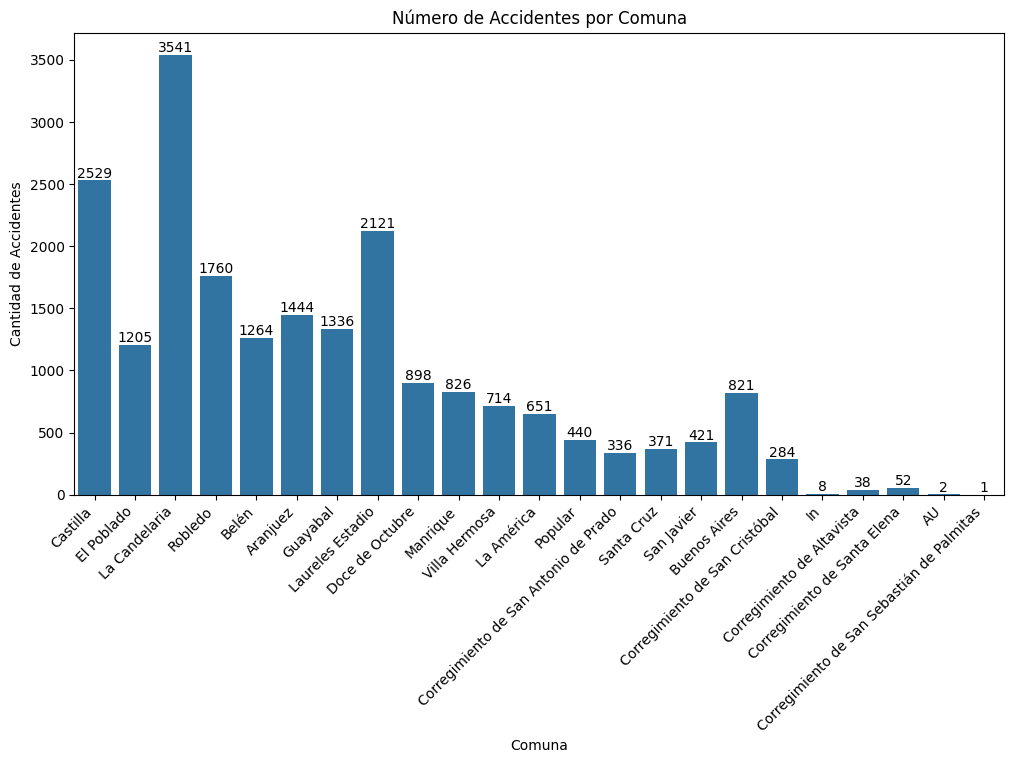

In [108]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(x='COMUNA', data=data_grav)

# Añadir las cantidades encima de las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title('Número de Accidentes por Comuna')
plt.xlabel('Comuna')
plt.ylabel('Cantidad de Accidentes')
plt.xticks(rotation=45, ha='right')
plt.show()

La comuna donde hay mayor cantidad de accidentes es La Candelaria con gran diferencia, seguida por Laureles Estadio y Castilla.

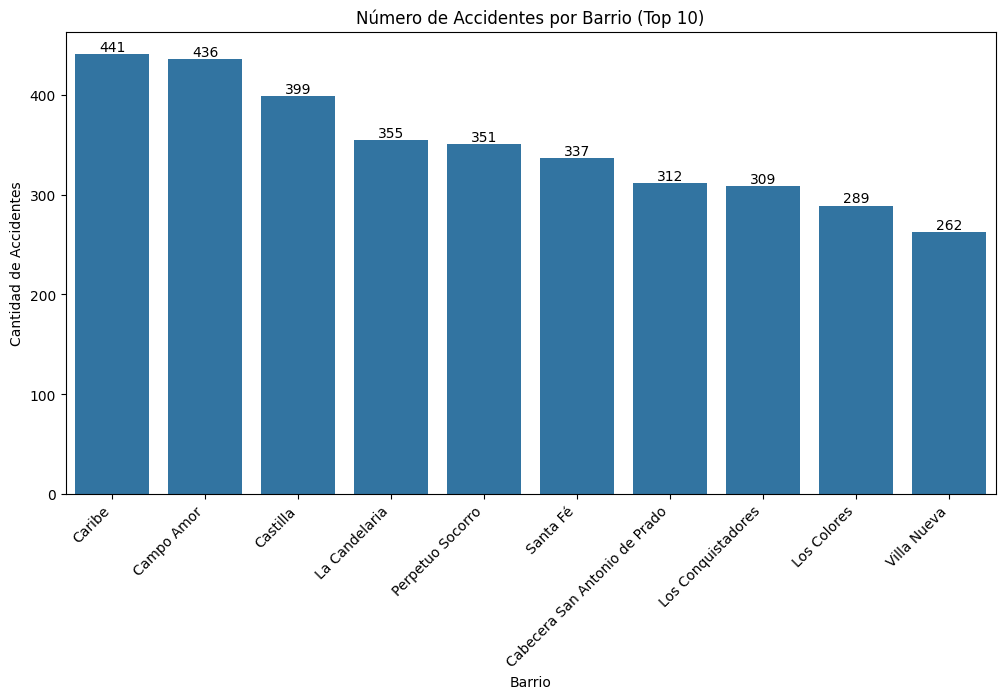

In [109]:
plt.figure(figsize=(12, 6))
barrio_counts = data_grav['BARRIO'].value_counts().nlargest(10)  # Top 10 barrios
ax = sns.barplot(x=barrio_counts.index, y=barrio_counts.values)

# Añadir las cantidades encima de las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title('Número de Accidentes por Barrio (Top 10)')
plt.xlabel('Barrio')
plt.ylabel('Cantidad de Accidentes')
plt.xticks(rotation=45, ha='right')
plt.show()

Este gráfico muestra el top 10 de los barrios con mayor cantidad de accidentes, en este top 10, el extremo inferior lo ocupa Villa Nueva y el extremo superior lo ocupa Caribe.

De este top 10, La Candelaria que ocupa el top 4 y Perpetuo Socorro que ocupa el top 5 pertenecen a la comuna de La Candelaria, la comuna que registra la mayor cantidad de accidentes.

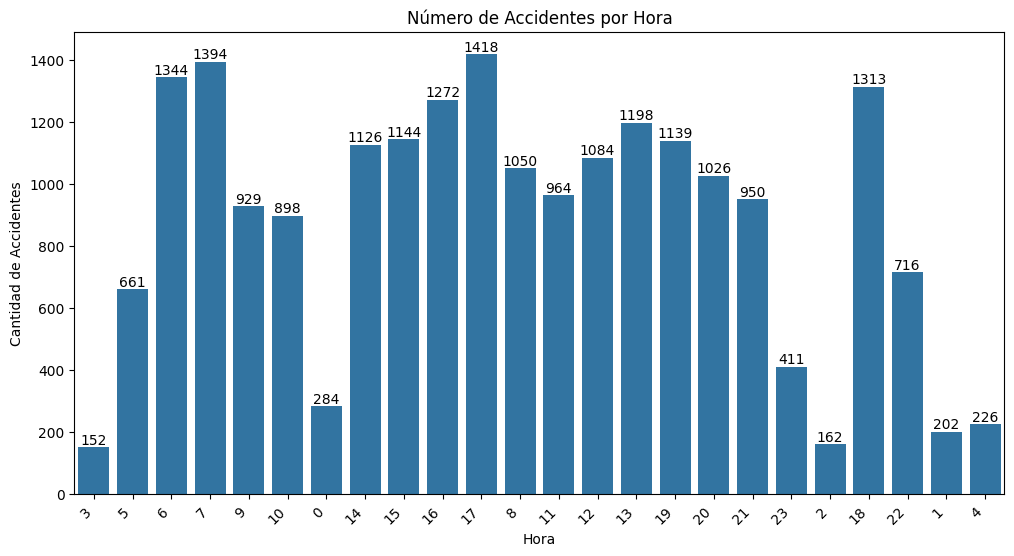

In [110]:

plt.figure(figsize=(12, 6))
ax = sns.countplot(x='RANGO_HORA', data=data_grav)

# Añadir las cantidades encima de las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title('Número de Accidentes por Hora')
plt.xlabel('Hora')
plt.ylabel('Cantidad de Accidentes')
plt.xticks(rotation=45, ha='right')
plt.show()

Este gráfico muestra la cantidad de accidentes por hora.

Los rangos están catalogados según la primera hora de cada rango, por ejemplo, el rango entre 6 y 7 de la mañana, se cataloga 6 y el rango 1 y 2 de la tarde se cataloga 13.

Se ve que entre las 0 y las 5 ocurren la menor cantidad de accidentes, que el rango horario en el que ocurren más accidentes es el que comprende de las 5 a las 6 de la tarde con 1418 accidentes y que entre 6 y 9 de la mañana y a partir de las 12 hasta las 9 de la noche ocurren más de 1000 accidentes por hora.





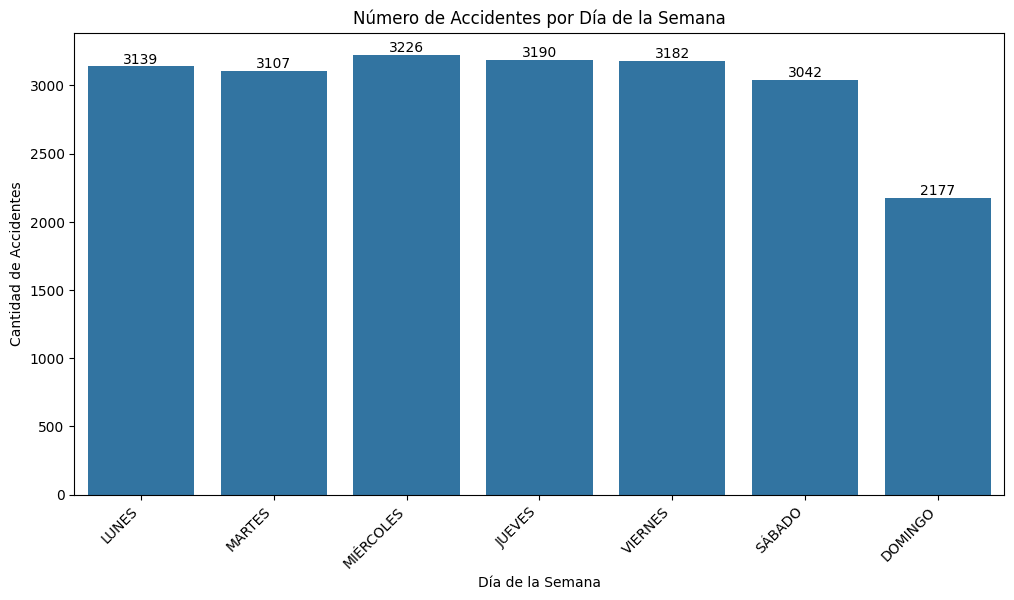

In [111]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(x='DIA_NOMBRE', data=data_grav, order=['LUNES', 'MARTES', 'MIÉRCOLES', 'JUEVES', 'VIERNES', 'SÁBADO', 'DOMINGO'])

# Añadir las cantidades encima de las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title('Número de Accidentes por Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Cantidad de Accidentes')
plt.xticks(rotation=45, ha='right')
plt.show()

Este gráfico muestra un equilibrio en la cantidad de accidentes por día entre los lunes y los sábados, con una disminución considerable los domingos. Entre los 7 días de la semana, el día con la mayor cantidad de accidentes es el miércoles seguido de cerca por el jueves, con una diferencia de 36 accidentes entre ambos días.

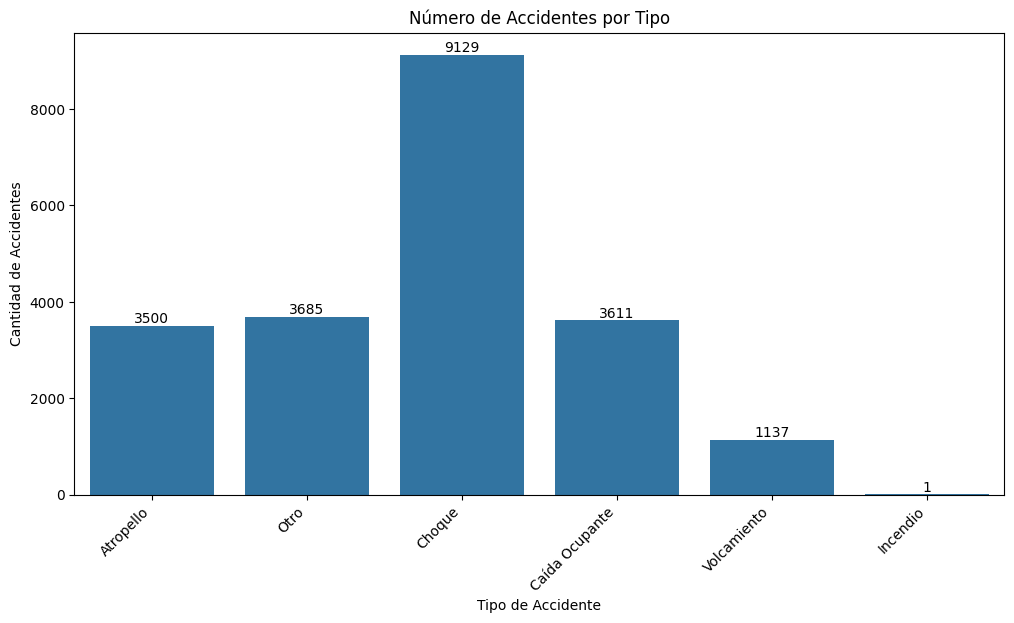

In [112]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(x='CLASE', data=data_grav)

# Añadir las cantidades encima de las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title('Número de Accidentes por Tipo')
plt.xlabel('Tipo de Accidente')
plt.ylabel('Cantidad de Accidentes')
plt.xticks(rotation=45, ha='right')
plt.show()

Este gráfico muestra la cantidad de accidentes que hay por cada tipo de accidente, el accidente que más ocurre es el choque de vehículos seguido por otro tipo de accidentes no definidos, la caída de ocupante y el atropello son las categorías que le siguen a la categoría (otro), los volcamientos ocurren en menor medida pero aún así ocurren más de 1000 y por último, el tipo de accidente menos recurrente puede ser el más peligroso, los incedios.

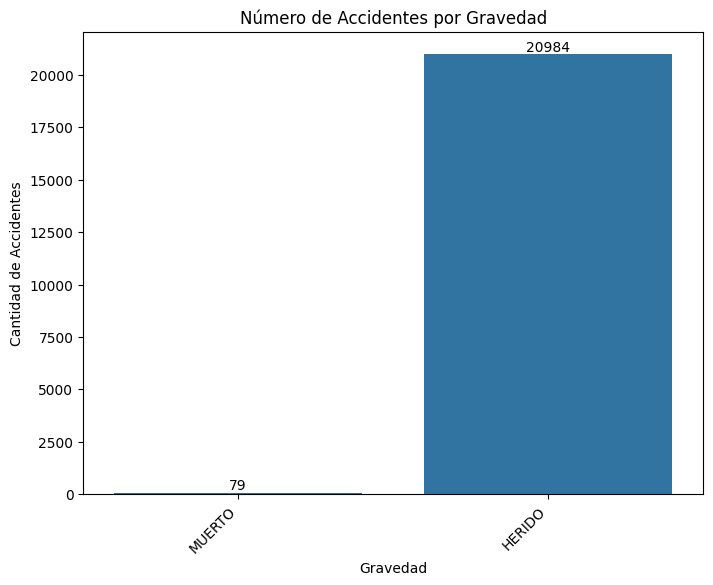

In [113]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='GRAVEDAD', data=data_grav)

# Añadir las cantidades encima de las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title('Número de Accidentes por Gravedad')
plt.xlabel('Gravedad')
plt.ylabel('Cantidad de Accidentes')
plt.xticks(rotation=45, ha='right')
plt.show()

Esta gráfica divide la cantidad de accidentes por su gravedad, la cantidad de accidentes que provocan heridos superan los 20000, los accidentes que provocan muertes son muy inferiores, por debajo de las 100.

# Desarrollo de modelos


In [114]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [115]:
data_grav.columns # Para conocer el nombre de las columnas

Index(['OBJECTID', 'FECHA', 'HORA', 'DIA', 'CLASE', 'DIRECCION', 'GRAVEDAD',
       'BARRIO', 'COMUNA', 'DISENO', 'DIA_NOMBRE', 'MES', 'LONGITUD',
       'LATITUD', 'z_X', 'z_Y', 'RANGO_HORA'],
      dtype='object')

# KMEANS

In [116]:
data_grav_cat=data_grav[['LATITUD','LONGITUD']]


In [117]:
data_grav_cat.head()

,LATITUD,LONGITUD
0,6.299676,-75.565634
3,6.219092,-75.569627
4,6.240001,-75.575473
5,6.301392,-75.563815
6,6.276391,-75.597087


In [118]:
corr_matrix = data_grav_cat.corr()
corr_matrix

,LATITUD,LONGITUD
LATITUD,1.00000,0.26835
LONGITUD,0.26835,1.00000


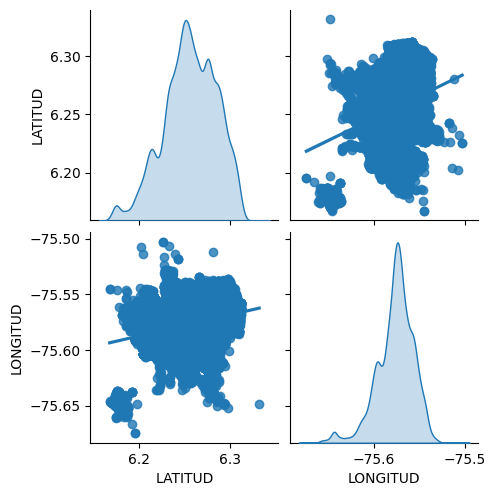

In [119]:
sns.pairplot(data_grav_cat, kind="reg", diag_kind="kde")
plt.show()


# *Estandarización de variables*

In [120]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data_grav_cat)
scaled_features

array([[ 1.53718094,  0.5499549 ],
       [-1.27720684,  0.35225715],
       [-0.54695212,  0.06275993],
       ...,
       [-0.57362535,  0.08057396],
       [ 0.89204529, -1.42507958],
       [ 1.29660431,  0.69822339]])

In [121]:
est=pd.DataFrame(scaled_features, columns=data_grav_cat.columns)
est

,LATITUD,LONGITUD
0,1.537181,0.549955
1,-1.277207,0.352257
2,-0.546952,0.062760
3,1.597127,0.640064
4,0.723976,-1.007475
...,...,...
21058,1.782254,1.049648
21059,-1.537345,-0.210710
21060,-0.573625,0.080574
21061,0.892045,-1.425080


In [145]:
kmeans = KMeans(
  init="random", # Este parámetro determina donde se ubican los centroides inicialmente
  n_clusters=5, # Corresponde al número de clusters que se van a crear
  n_init=10, # El número de veces que se iniciarán los centroides para seleccionar los mejores, según la inercia
  max_iter=300, # Número máximo de iteraciones para encontrar los clusters optimos
  random_state=42 # Este valor asegura que los resultados son reproducibles
  )

In [123]:
kmeans.fit(scaled_features)

KMeans(init='random', n_clusters=5, n_init=10, random_state=42)

In [124]:
kmeans.inertia_ # es la medida de la suma de las distancias al cuadrado entre cada punto y el centroide.
# Entre menor sea este valor, generalmente indica una mejor clusterización.
# Pero esta no debería ser la medida que determina el número de clusters.

10583.479781760658

In [125]:
kmeans.cluster_centers_ # Muestra los centroides de los clusters

array([[-2.69391241, -3.43389094],
       [ 1.15730971,  0.46365476],
       [-1.24403239, -0.20204186],
       [-0.12335359,  0.69183084],
       [ 0.1684969 , -1.1879896 ]])

In [126]:
standardized_centroids = kmeans.cluster_centers_

original_centroids = scaler.inverse_transform(standardized_centroids)
original_centroids

array([[  6.17852743, -75.64608936],
       [  6.28879882, -75.56737717],
       [  6.2200416 , -75.58082113],
       [  6.25212981, -75.56276908],
       [  6.26048631, -75.60073266]])

In [127]:
labels = kmeans.predict(scaled_features)
data_grav['cluster'] = labels
data_grav

<ipython-input-127-cf8ad2f6a4b1>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_grav['cluster'] = labels


,OBJECTID,FECHA,HORA,DIA,CLASE,DIRECCION,GRAVEDAD,BARRIO,COMUNA,DISENO,DIA_NOMBRE,MES,LONGITUD,LATITUD,z_X,z_Y,RANGO_HORA,cluster
0,549556,02/01/2018,03:18:00,2,Atropello,CR 64 C CL 103 GG,MUERTO,Girardot,Castilla,Tramo de via,MARTES,1,-75.565634,6.299676,0.548430,1.784761,3,1
3,549559,02/01/2018,05:26:00,2,Otro,CR 43 A CL 17,HERIDO,Castropol,El Poblado,Lote o Predio,MARTES,1,-75.569627,6.219092,0.441694,-1.031431,5,2
4,549560,02/01/2018,05:45:00,2,Choque,CR 55 CL 37,HERIDO,Calle Nueva,La Candelaria,Tramo de via,MARTES,1,-75.575473,6.240001,0.285397,-0.300708,5,2
5,549561,02/01/2018,06:00:00,2,Otro,CR 64 C CL 104,HERIDO,Las Brisas,Castilla,Tramo de via,MARTES,1,-75.563815,6.301392,0.597079,1.844745,6,1
6,549562,02/01/2018,06:30:00,2,Otro,CL 65 CR 87,HERIDO,Robledo,Robledo,Lote o Predio,MARTES,1,-75.597087,6.276391,-0.292416,0.971035,6,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43441,686832,01/12/2018,10:20:00,1,Volcamiento,CR 52 CL 123,HERIDO,Playón de Los Comuneros,Santa Cruz,Lote o Predio,SÁBADO,12,-75.555543,6.306693,0.818211,2.029991,10,1
43442,686833,01/12/2018,10:35:00,1,Choque,CL 6 CR 51,HERIDO,Campo Amor,Guayabal,Paso Elevado,SÁBADO,12,-75.580996,6.211643,0.137752,-1.291736,10,2
43445,686836,01/12/2018,10:50:00,1,Otro,CR 54 CL 37,HERIDO,Calle Nueva,La Candelaria,Glorieta,SÁBADO,12,-75.575114,6.239237,0.295014,-0.327399,10,2
43446,686837,01/12/2018,11:00:00,1,Caída Ocupante,CL 65 CR 97,HERIDO,Pajarito,Robledo,Tramo de via,SÁBADO,12,-75.605521,6.281204,-0.517878,1.139212,11,4


*Número de clusters a crear*

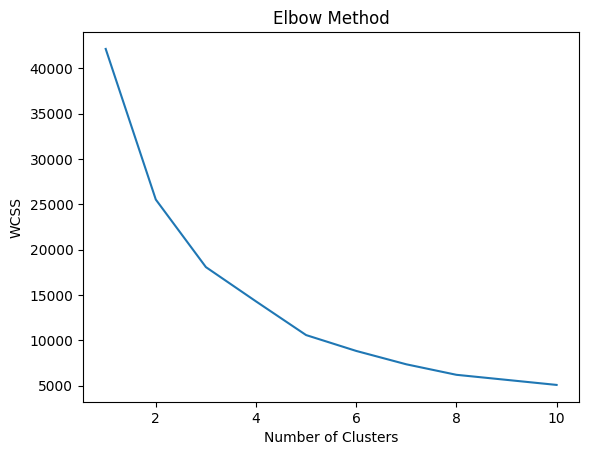

In [128]:
wcss = [] # crear una lista para almacenar los valores de WCSS

# Calcular el WCSS para diferentes valores de k
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Gráfico del codo
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [129]:

cluster_counts = data_grav['cluster'].value_counts()
cluster_counts


,count
cluster,
3,6488
1,5607
2,4397
4,4227
0,344


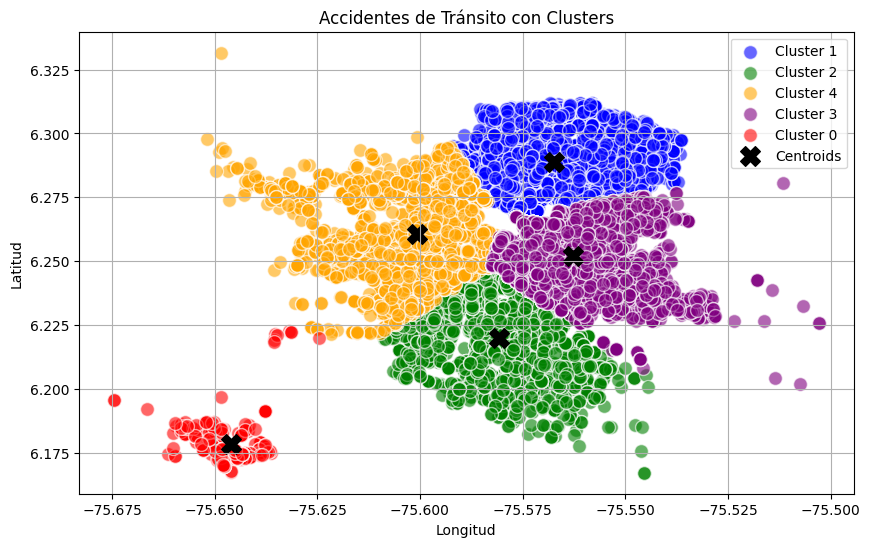

In [130]:
import matplotlib.pyplot as plt

# Assuming 'data_grav' DataFrame exists with 'LATITUD', 'LONGITUD', and 'cluster' columns
# and 'original_centroids' array contains the centroids in the original scale

# Create the scatter plot
plt.figure(figsize=(10, 6))

# Define a color palette for the clusters
colors = ['red', 'blue', 'green', 'purple', 'orange']

for cluster_id in data_grav['cluster'].unique():
    cluster_data = data_grav[data_grav['cluster'] == cluster_id]
    plt.scatter(cluster_data['LONGITUD'], cluster_data['LATITUD'],
                label=f'Cluster {cluster_id}', color=colors[cluster_id % len(colors)], alpha=0.6, edgecolors='w', s=100)

# Plot the centroids
plt.scatter(original_centroids[:, 1], original_centroids[:, 0], s=200, c='black', marker='X', label='Centroids')


# Customize the plot
plt.title('Accidentes de Tránsito con Clusters')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(True)
plt.legend()
plt.show()


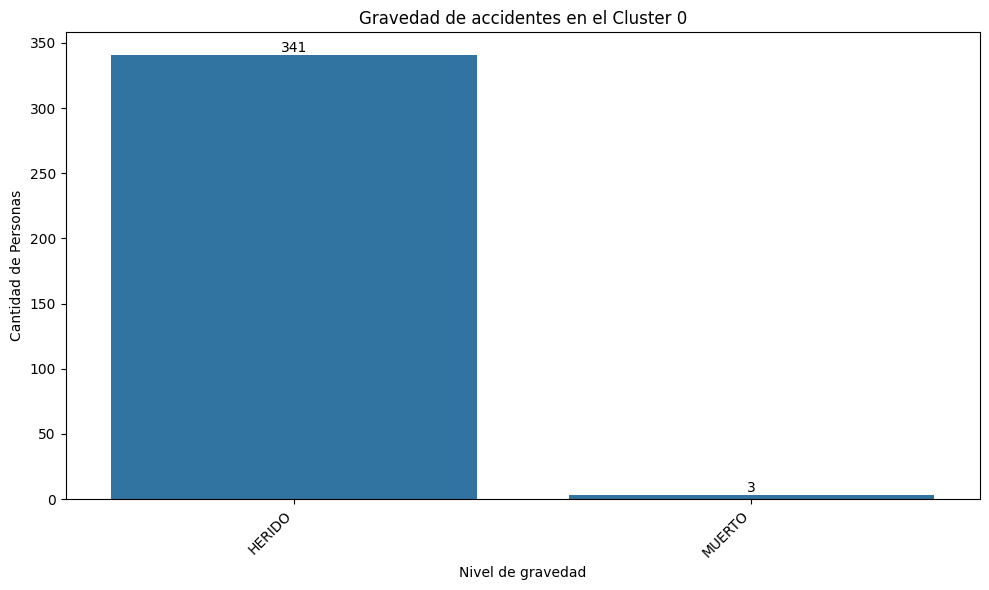

In [131]:
# Filtrar los datos del cluster 0
cluster_0 = data_grav[data_grav['cluster'] == 0]

# Contar la frecuencia de cada nivel de gravedad en el cluster 0
gravedad_counts = cluster_0['GRAVEDAD'].value_counts()

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
bar_plot = sns.barplot(x=gravedad_counts.index, y=gravedad_counts.values)

# Añadir las cantidades encima de cada barra
for p in bar_plot.patches:
    bar_plot.annotate(f'{int(p.get_height())}',
                      (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='bottom', fontsize=10)

plt.title('Gravedad de accidentes en el Cluster 0')
plt.xlabel('Nivel de gravedad')
plt.ylabel('Cantidad de Personas')
plt.xticks(rotation=45, ha='right')  # Rotar etiquetas del eje x para mejor legibilidad
plt.tight_layout()  # Ajustar el diseño para que no se corten las etiquetas
plt.show()

En este cluster, más del 99% de los accidentes dejan heridos y solo el 0,87% (3) provocan muertes.

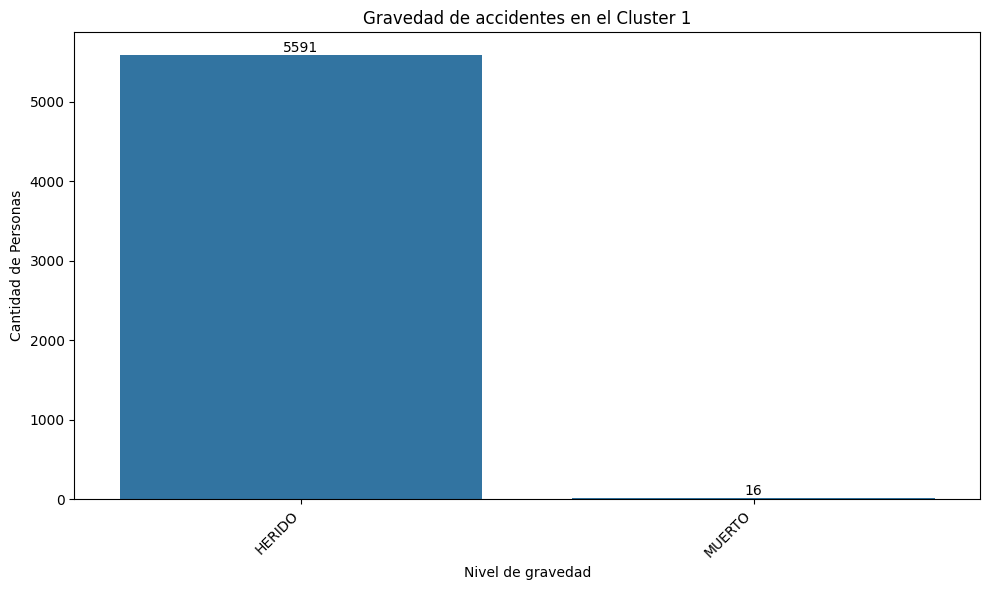

In [132]:
# Filtrar los datos del cluster 1
cluster_1 = data_grav[data_grav['cluster'] == 1]

# Contar la frecuencia de cada nivel de gravedad en el cluster 1
gravedad_counts = cluster_1['GRAVEDAD'].value_counts()

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
bar_plot = sns.barplot(x=gravedad_counts.index, y=gravedad_counts.values)

# Añadir las cantidades encima de cada barra
for p in bar_plot.patches:
    bar_plot.annotate(f'{int(p.get_height())}',
                      (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='bottom', fontsize=10)

plt.title('Gravedad de accidentes en el Cluster 1')
plt.xlabel('Nivel de gravedad')
plt.ylabel('Cantidad de Personas')
plt.xticks(rotation=45, ha='right')  # Rotar etiquetas del eje x para mejor legibilidad
plt.tight_layout()  # Ajustar el diseño para que no se corten las etiquetas
plt.show()

En este cluster, el 99,69% de los accidentes dejan heridos y menos del 0,3% (16) provoca muertes.

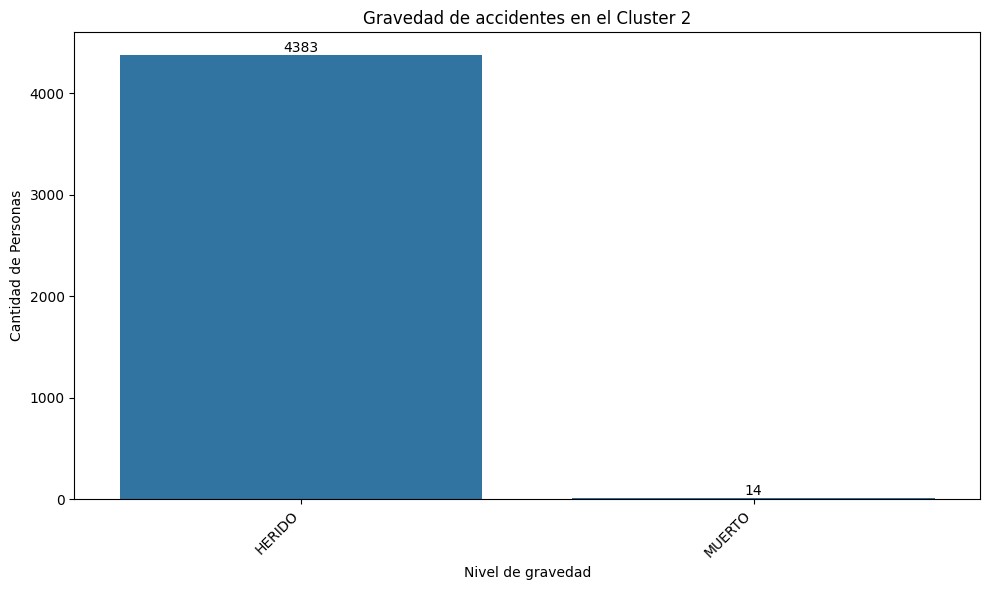

In [133]:
# Filtrar los datos del cluster 2
cluster_2 = data_grav[data_grav['cluster'] == 2]

# Contar la frecuencia de cada nivel de gravedad en el cluster 2
gravedad_counts = cluster_2['GRAVEDAD'].value_counts()

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
bar_plot = sns.barplot(x=gravedad_counts.index, y=gravedad_counts.values)

# Añadir las cantidades encima de cada barra
for p in bar_plot.patches:
    bar_plot.annotate(f'{int(p.get_height())}',
                      (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='bottom', fontsize=10)

plt.title('Gravedad de accidentes en el Cluster 2')
plt.xlabel('Nivel de gravedad')
plt.ylabel('Cantidad de Personas')
plt.xticks(rotation=45, ha='right')  # Rotar etiquetas del eje x para mejor legibilidad
plt.tight_layout()  # Ajustar el diseño para que no se corten las etiquetas
plt.show()

En este cluster, el 99,68% de los accidentes deja heridos y menos del 0,5% (14) provoca muertes.

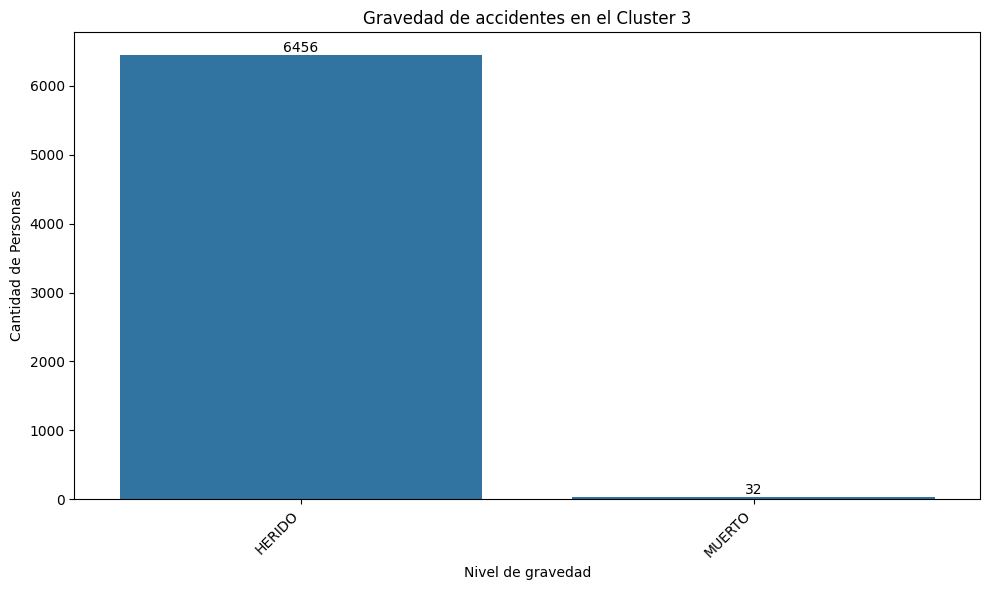

In [134]:
# Filtrar los datos del cluster 3
cluster_3 = data_grav[data_grav['cluster'] == 3]

# Contar la frecuencia de cada nivel de gravedad en el cluster 3
gravedad_counts = cluster_3['GRAVEDAD'].value_counts()

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
bar_plot = sns.barplot(x=gravedad_counts.index, y=gravedad_counts.values)

# Añadir las cantidades encima de cada barra
for p in bar_plot.patches:
    bar_plot.annotate(f'{int(p.get_height())}',
                      (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='bottom', fontsize=10)

plt.title('Gravedad de accidentes en el Cluster 3')
plt.xlabel('Nivel de gravedad')
plt.ylabel('Cantidad de Personas')
plt.xticks(rotation=45, ha='right')  # Rotar etiquetas del eje x para mejor legibilidad
plt.tight_layout()  # Ajustar el diseño para que no se corten las etiquetas
plt.show()

En este cluster, el 99,5% de los accidentes generan heridos y menos del 0,5% (32) provoca muertes.

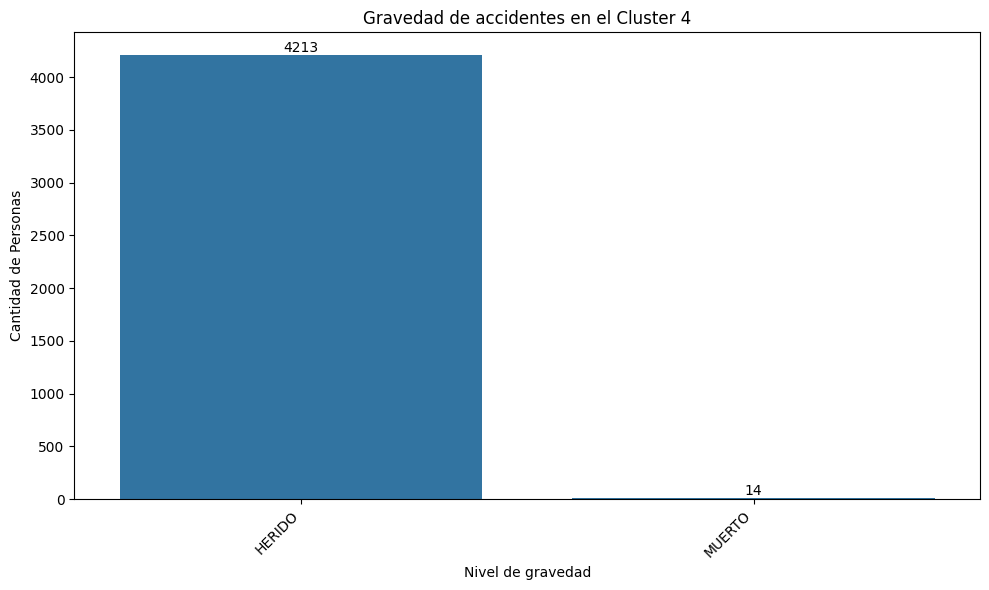

In [135]:
# Filtrar los datos del cluster 4
cluster_4 = data_grav[data_grav['cluster'] == 4]

# Contar la frecuencia de cada nivel de gravedad en el cluster 4
gravedad_counts = cluster_4['GRAVEDAD'].value_counts()

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
bar_plot = sns.barplot(x=gravedad_counts.index, y=gravedad_counts.values)

# Añadir las cantidades encima de cada barra
for p in bar_plot.patches:
    bar_plot.annotate(f'{int(p.get_height())}',
                      (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='bottom', fontsize=10)

plt.title('Gravedad de accidentes en el Cluster 4')
plt.xlabel('Nivel de gravedad')
plt.ylabel('Cantidad de Personas')
plt.xticks(rotation=45, ha='right')  # Rotar etiquetas del eje x para mejor legibilidad
plt.tight_layout()  # Ajustar el diseño para que no se corten las etiquetas
plt.show()

En este cluster, el 99,67% de los accidentes generan heridos y menos del 0,4% (14) provoca muertes.

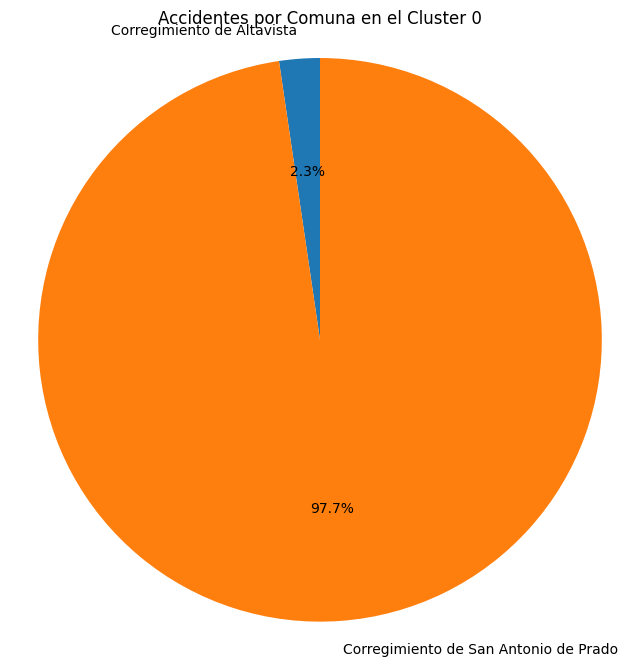

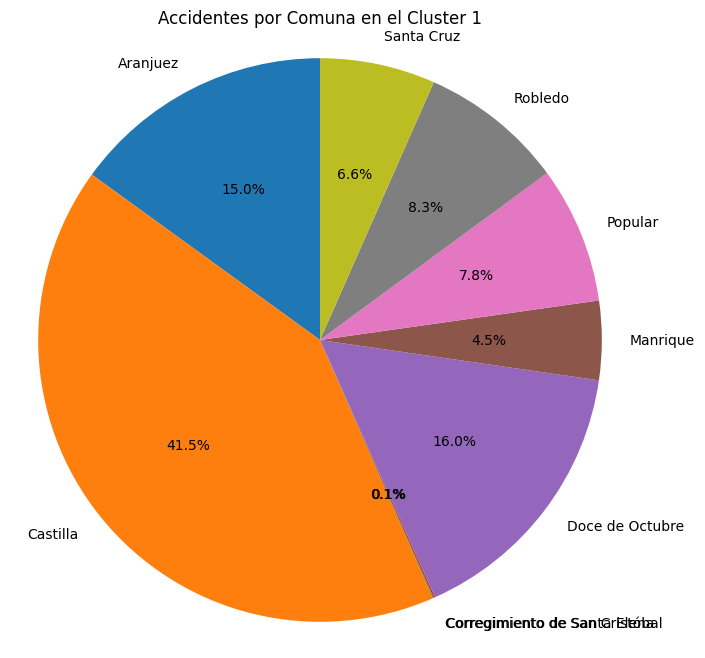

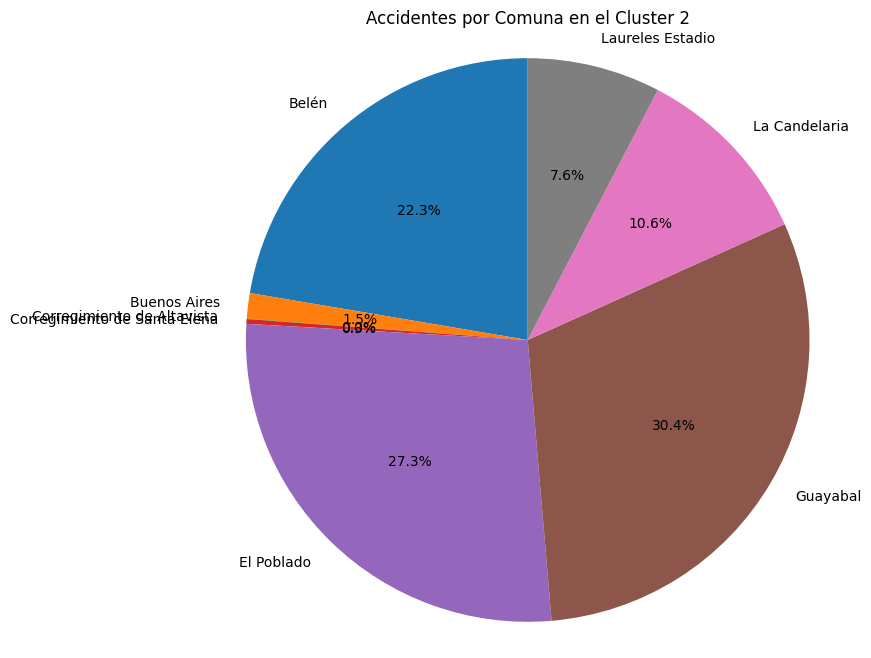

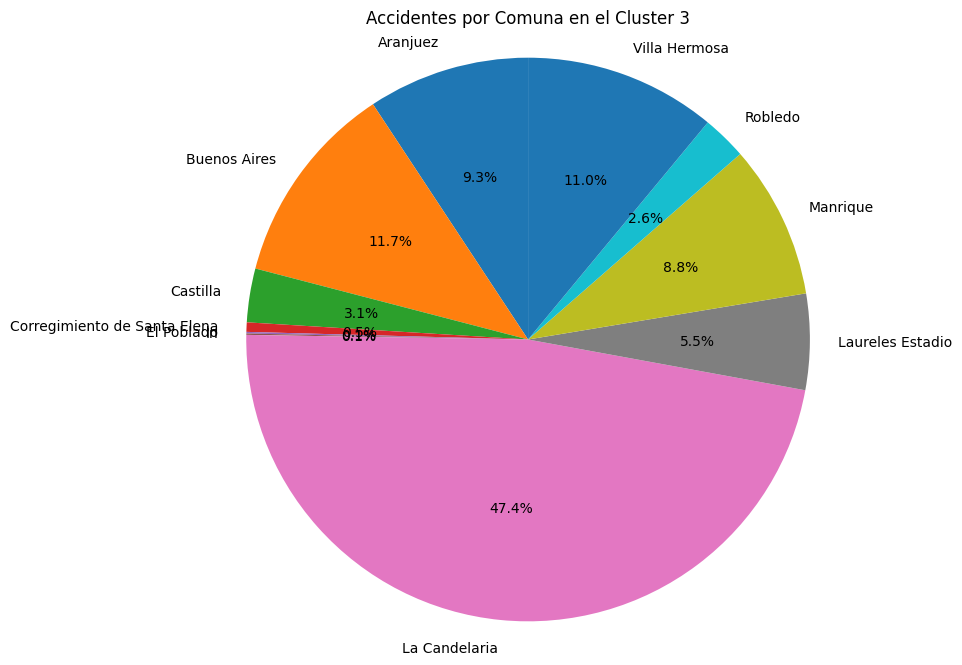

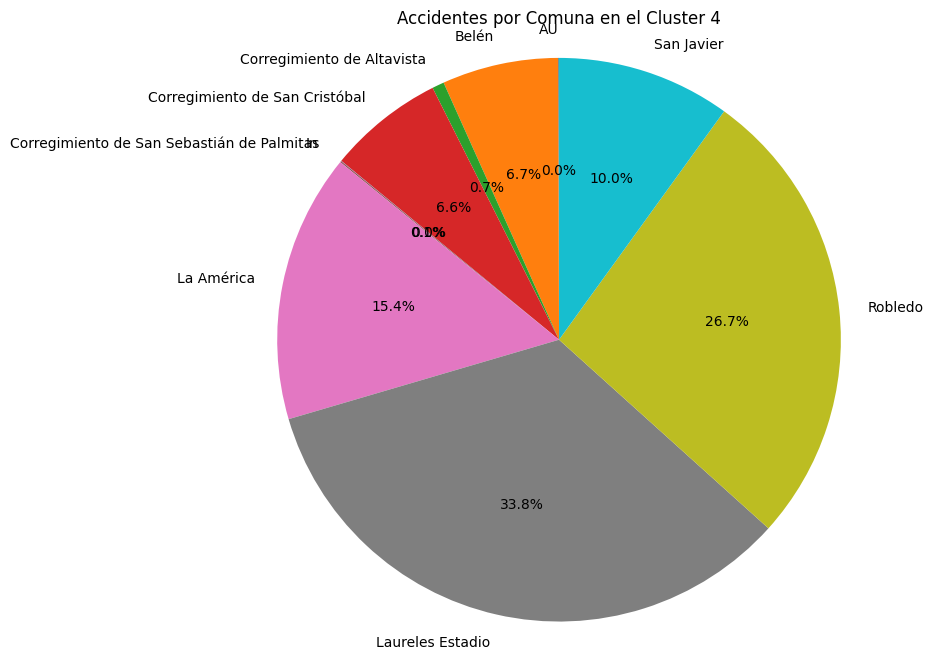

In [136]:
cluster_pie_charts = []

# Iterate through unique cluster values
for cluster_id in sorted(data_grav['cluster'].unique()):
    # Filter the DataFrame for the current cluster
    cluster_data = data_grav[data_grav['cluster'] == cluster_id]

    # Group by comuna and count the number of accidents for each comuna within the cluster
    comuna_counts = cluster_data.groupby('COMUNA')['GRAVEDAD'].count()

    # Create a pie chart for the current cluster
    plt.figure(figsize=(8, 8))
    plt.pie(comuna_counts, labels=comuna_counts.index, autopct='%1.1f%%', startangle=90)
    plt.title(f'Accidentes por Comuna en el Cluster {cluster_id}')
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

    # Append the pie chart to the list
    cluster_pie_charts.append(plt)

# Display all pie charts in order
for chart in cluster_pie_charts:
    chart.show()


En esta gráfica se puede ver la distribución de los accidentes entre las distintas comunas por cluster.

En el cluster 0 el mayor porcentaje de accidentes ocurren en el Corregimiento de San Antonio de Prado

En el cluster 1 el mayor porcenttaje de accidentes ocurren en Castilla, Doce de Octubre y Aranjuez.

En el cluster 2 el mayor porcentaje de accidentes ocurren en Guayabal, El Poblado y Belén.

En el cluster 3 el mayor porcentaje de accidentes ocurren en La Candelaria, Buenos Aires y Villa Hermosa.

En el cluster 4 el mayor porcentaje de accidentes ocurren en Laureles Estadio, Robledo, La América y San Javier.

Por ende, estas son las comunas en las que sería necesario prestar más atención al distribuir agentes de tránsito y ambulancias.

RANGO_HORA         0         1        10        11        12        13  \
cluster                                                                  
0           1.453488  0.581395  3.779070  4.069767  6.976744  3.779070   
1           1.747815  1.123596  4.102015  4.191190  5.189941  5.564473   
2           1.410052  0.636798  4.275642  5.208096  5.185354  6.254264   
3           1.186806  1.202219  4.284834  4.716400  5.024661  5.517879   
4           0.993612  0.733381  4.471256  4.258339  5.086350  5.677786   

RANGO_HORA        14        15        16        17  ...        21        22  \
cluster                                             ...                       
0           5.232558  5.813953  4.941860  7.848837  ...  6.104651  2.906977   
1           5.261281  5.368290  5.617978  6.331371  ...  5.421794  3.852327   
2           5.867637  5.435524  6.413464  6.754605  ...  4.093700  3.024790   
3           4.993835  5.440814  6.381011  6.750925  ...  3.945746  3.437115   
4      

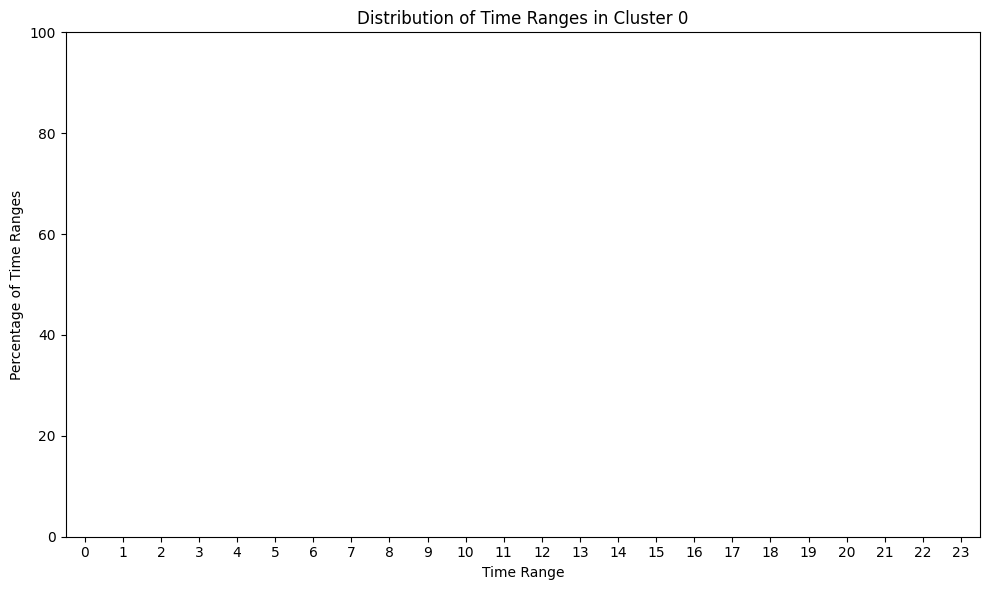

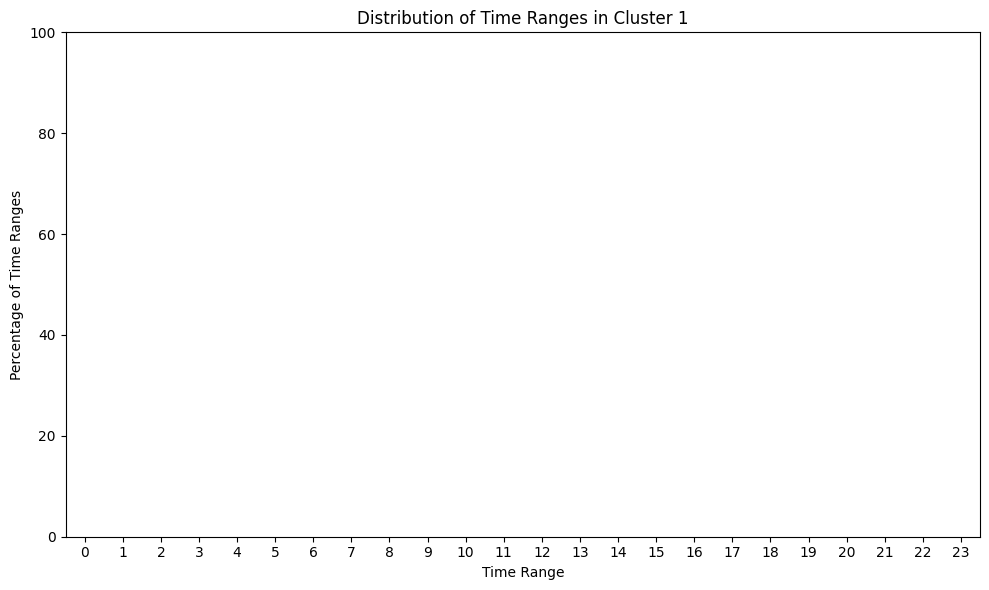

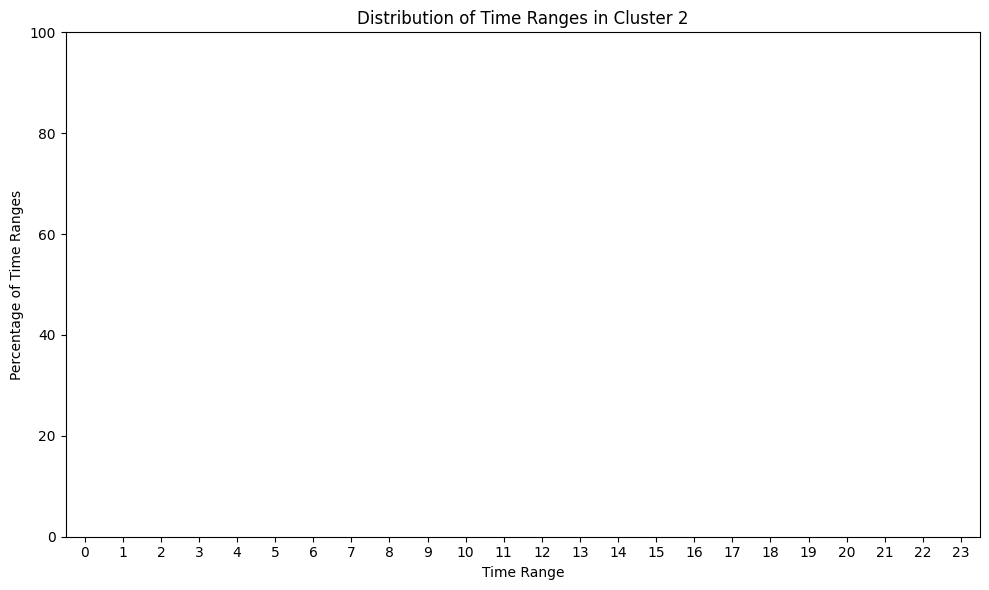

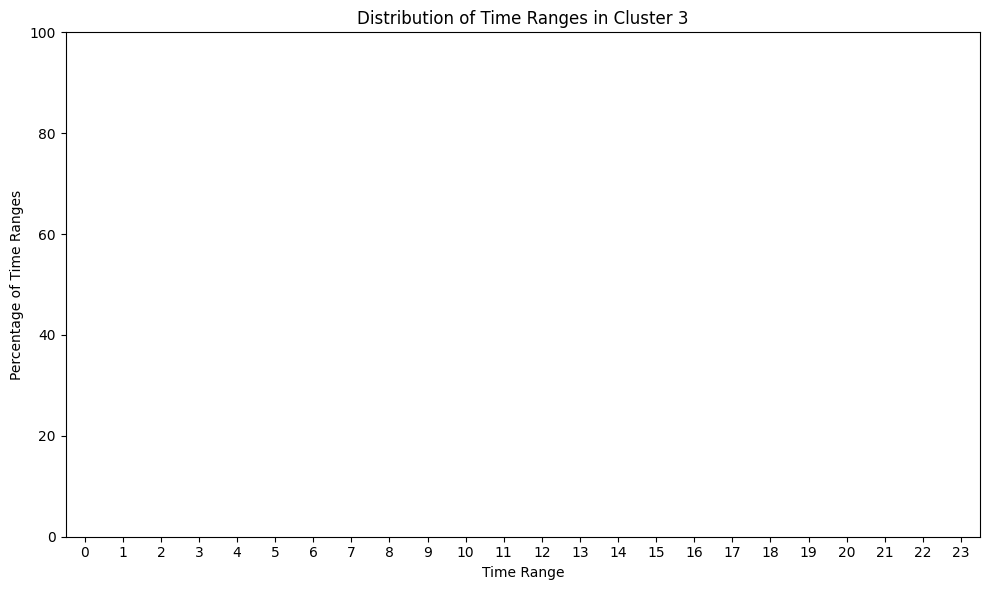

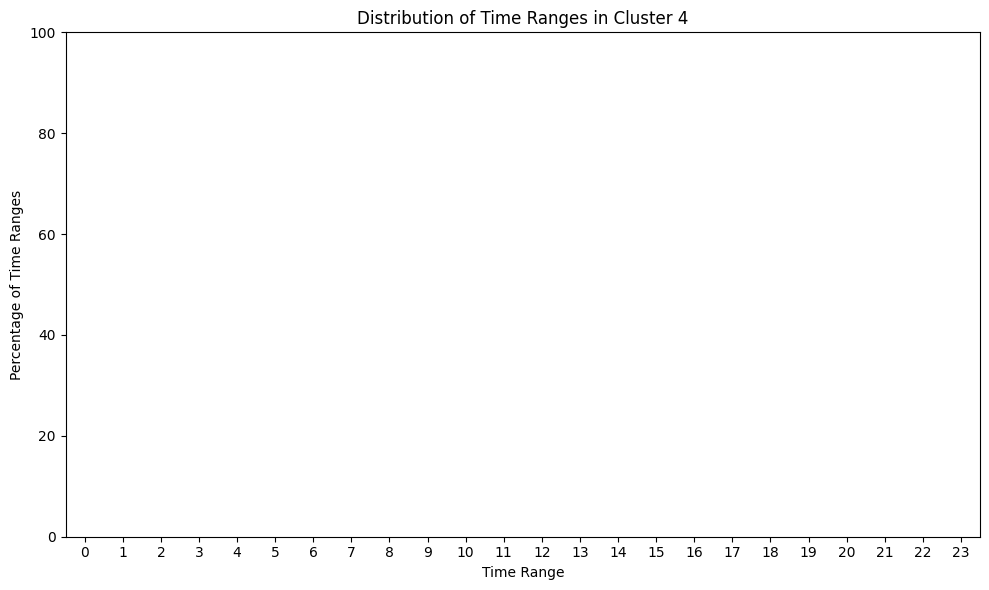

In [137]:
import pandas as pd
import matplotlib.pyplot as plt

# Agrupar datos por cluster y rango horario
cluster_time_counts = data_grav.groupby(['cluster', 'RANGO_HORA'])['RANGO_HORA'].count().unstack()

# Calcular el porcentaje de cada rango horario dentro de cada cluster
cluster_time_percentages = cluster_time_counts.div(cluster_time_counts.sum(axis=1), axis=0) * 100

# Mostrar los porcentajes
print(cluster_time_percentages)

# Crear gráficos individuales para cada cluster
num_clusters = cluster_time_percentages.index.tolist()  # Obtener la lista de clusters

# Definir todos los rangos horarios
all_time_ranges = range(24)  # Rango de 0 a 23

for cluster in num_clusters:
    plt.figure(figsize=(10, 6))  # Tamaño de la figura
    # Obtener los porcentajes para el cluster actual, rellenando con 0 si no hay datos
    percentages = cluster_time_percentages.loc[cluster].reindex(all_time_ranges, fill_value=0)

    plt.bar(percentages.index, percentages, color='skyblue', width=0.6)

    # Añadir etiquetas de porcentaje encima de las barras
    for i, height in enumerate(percentages):
        if height > 0:  # Solo añadir etiquetas si hay un valor
            plt.text(i, height, f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

    plt.title(f'Distribution of Time Ranges in Cluster {cluster}')
    plt.xlabel('Time Range')
    plt.ylabel('Percentage of Time Ranges')
    plt.xticks(all_time_ranges)  # Asegurarse de que todos los rangos horarios estén numerados
    plt.xlim(-0.5, 23.5)  # Ajustar límites del eje x para centrar las barras
    plt.ylim(0, 100)  # Limitar el eje y al 100%
    plt.tight_layout()
    plt.show()

Esta gráfica muestra la distribución de los accidentes entre los rangos horarios establecidos, al analizar cluster por cluster se puede encontrar lo siguiente:

*   Ocurren menos accidentes entre las 11 de la noche y las 5 de la mañana en todos los cluster.
*   cluster 0: De 7 a 8, 12 a 1 y 5 a 7 de la tarde hay picos en la cantidad de accidentes.
*   cluster 1: De 6 a 8 de la mañana hay picos de accidentes.
*   cluster 2: De 7 a 8 de la mañana y de 4 a 7 de la tarde hay picos de accidentes.
*   cluster 3: De 6 a 8 de la mañana y de 4 a 7 de la tarde hay picos de accidentes.
*   cluster 4: De 6 a 8 de la mañana y de 5 a 6 de la tarde hay picos de accidentes.

Por ende, de 6 a 8 de la mañana y de 4 a 7 de la tarde son los rangos horarios en los que se debe prestar especial atención al distribuir agentes de tránsito y ambulancias.

CLASE    Atropello  Caída Ocupante     Choque  Incendio       Otro  \
cluster                                                              
0        19.186047       13.372093  45.348837       NaN  14.534884   
1        18.423399       22.578919  35.598359       NaN  18.227216   
2        10.643621       11.576075  54.764612  0.022743  17.489197   
3        19.774969       14.935265  42.725031       NaN  16.831073   
4        15.377336       19.422758  42.512420       NaN  17.790395   

CLASE    Volcamiento  
cluster               
0           7.558140  
1           5.172106  
2           5.503753  
3           5.733662  
4           4.897090  


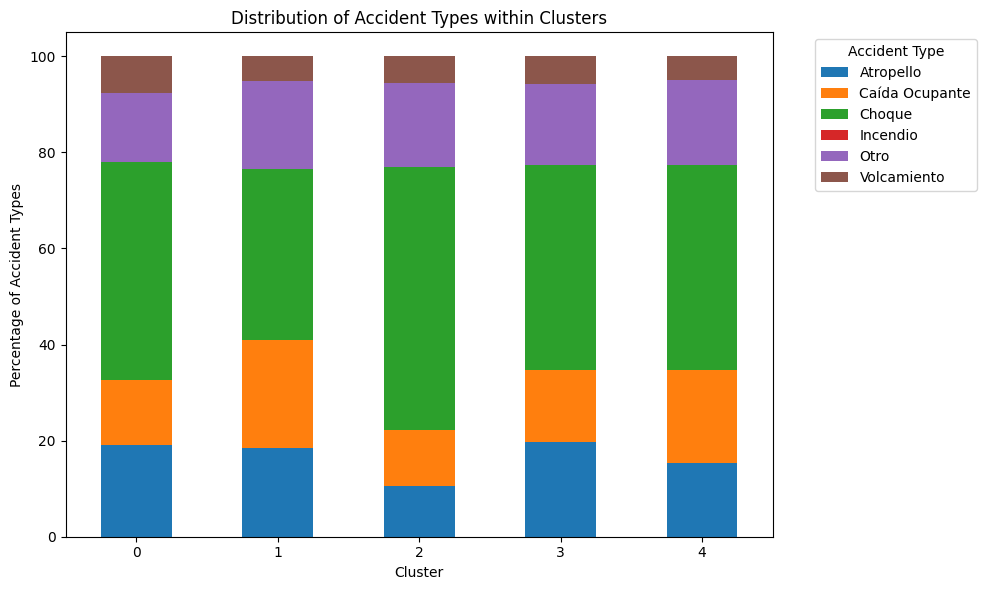

CLASE    Atropello  Caída Ocupante     Choque  Incendio       Otro  \
cluster                                                              
0        19.186047       13.372093  45.348837  0.000000  14.534884   
1        18.423399       22.578919  35.598359  0.000000  18.227216   
2        10.643621       11.576075  54.764612  0.022743  17.489197   
3        19.774969       14.935265  42.725031  0.000000  16.831073   
4        15.377336       19.422758  42.512420  0.000000  17.790395   

CLASE    Volcamiento  
cluster               
0           7.558140  
1           5.172106  
2           5.503753  
3           5.733662  
4           4.897090  


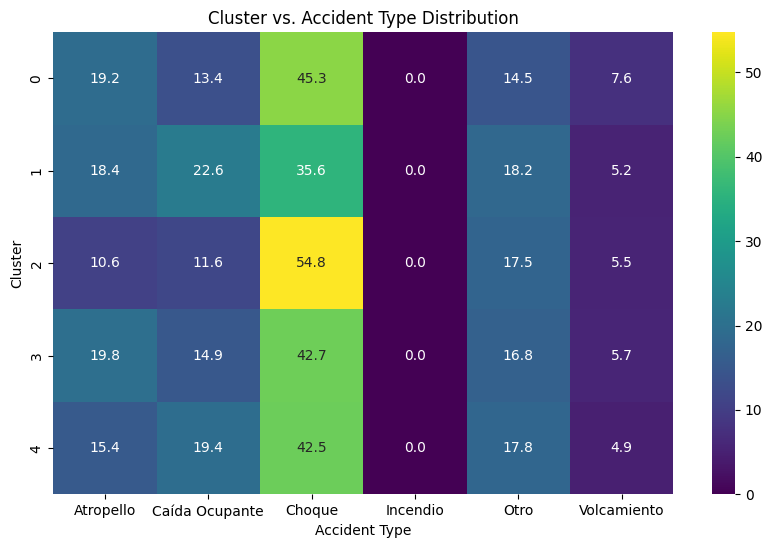

In [138]:
# Function to plot the distribution of 'CLASE' within each cluster
def plot_clase_distribution(data):
    cluster_clase_counts = data.groupby(['cluster', 'CLASE'])['CLASE'].count().unstack()
    cluster_clase_percentages = cluster_clase_counts.div(cluster_clase_counts.sum(axis=1), axis=0) * 100
    print(cluster_clase_percentages)

    cluster_clase_percentages.plot(kind='bar', stacked=True, figsize=(10, 6))
    plt.title('Distribution of Accident Types within Clusters')
    plt.xlabel('Cluster')
    plt.ylabel('Percentage of Accident Types')
    plt.xticks(rotation=0)
    plt.legend(title='Accident Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


# Call the function
plot_clase_distribution(data_grav)


# Function to create a cross-tabulation and plot the results
def analyze_cluster_vs_clase(data):
    # Create a cross-tabulation of cluster and CLASE
    cross_tab = pd.crosstab(data['cluster'], data['CLASE'], normalize='index') * 100
    print(cross_tab)

    # Plot the cross-tabulation as a heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(cross_tab, annot=True, cmap='viridis', fmt=".1f")
    plt.title('Cluster vs. Accident Type Distribution')
    plt.xlabel('Accident Type')
    plt.ylabel('Cluster')
    plt.show()


# Call the function
analyze_cluster_vs_clase(data_grav)


En este gráfico se evidencia la relación entre los accidentes de tránsito y sus distintos tipos.

El cluster 2 es el único en el que ocurren incedios, aunque ocurren en menos del 0,1% de los casos.

En todos los clusters el accidente que más ocurre es el choque.

En el cluster 0 y 3 el segundo tipo de accidente que más predomina es el atropello.

En el cluster 1 y 4 el tipo de accidente que más ocurre aparte del choque es la caída de ocupante.

En el cluster 2 el tipo de accidente con más presencia después de los choques es el que se denomina otro.

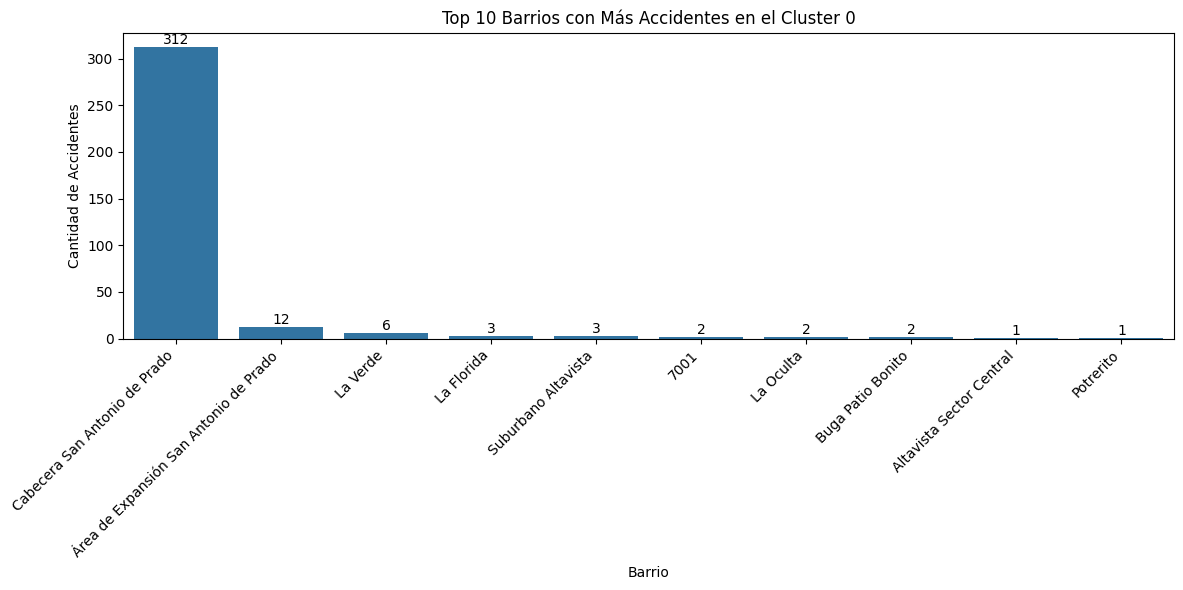

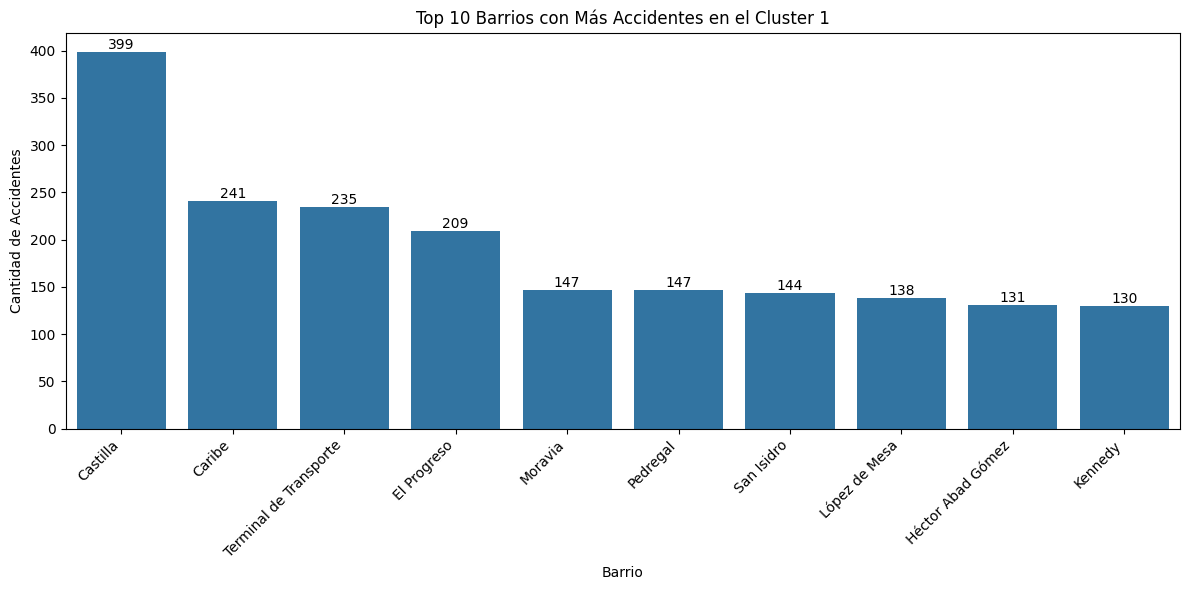

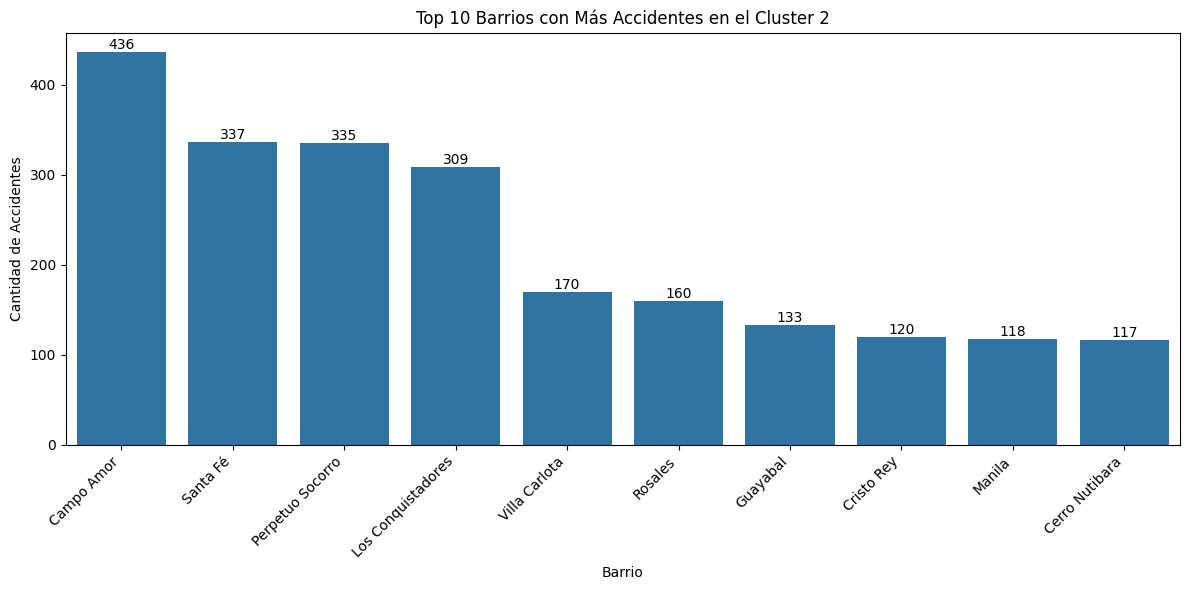

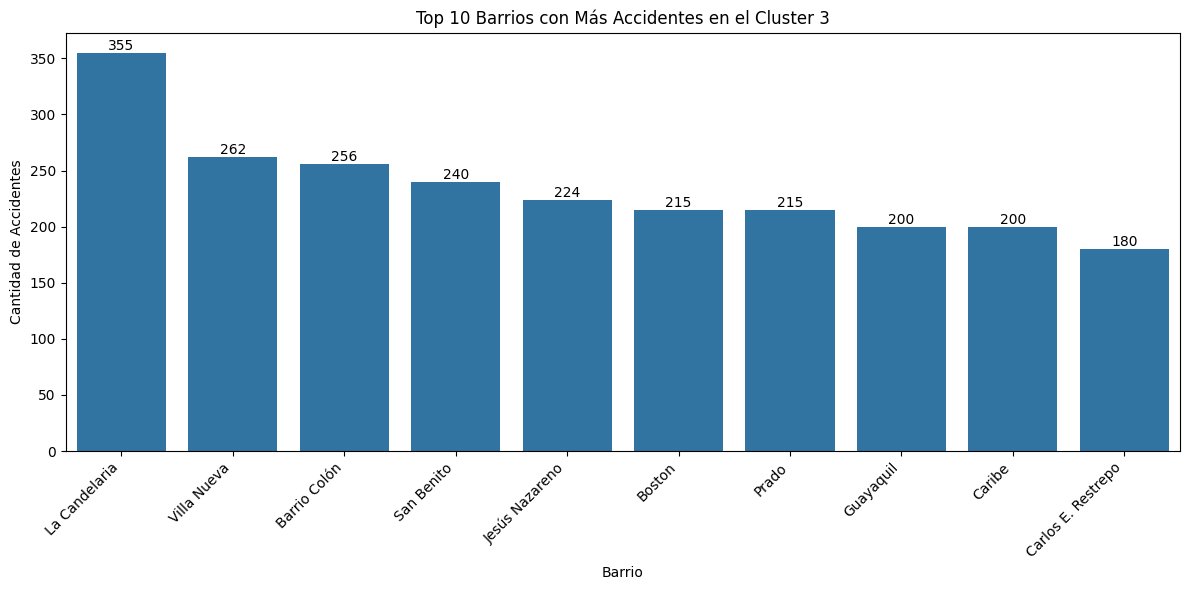

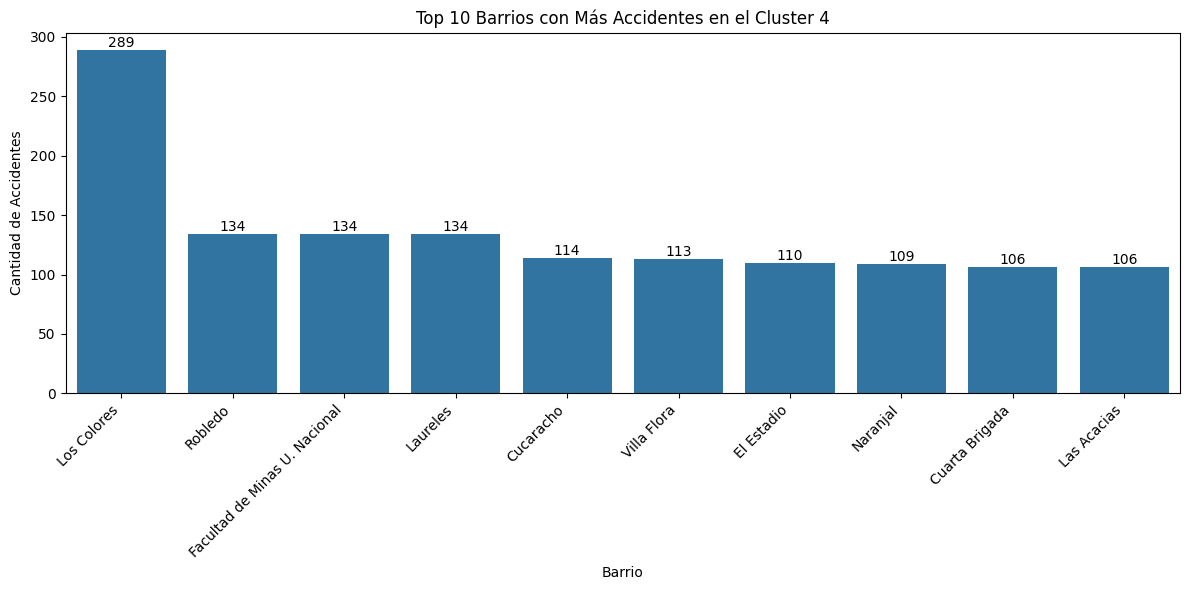

In [139]:
# Agrupar los datos por cluster y barrio, contando la cantidad de accidentes en cada grupo
cluster_barrio_counts = data_grav.groupby(['cluster', 'BARRIO'])['GRAVEDAD'].count().reset_index()

# Para cada cluster, obtener el top 10 de barrios con más accidentes
top_10_barrios_per_cluster = {}
for cluster_id in cluster_barrio_counts['cluster'].unique():
  cluster_data = cluster_barrio_counts[cluster_barrio_counts['cluster'] == cluster_id]
  top_10_barrios = cluster_data.sort_values('GRAVEDAD', ascending=False).head(10)
  top_10_barrios_per_cluster[cluster_id] = top_10_barrios


# Crear un gráfico para cada cluster
for cluster_id, top_10_data in top_10_barrios_per_cluster.items():
  plt.figure(figsize=(12, 6))
  ax = sns.barplot(x='BARRIO', y='GRAVEDAD', data=top_10_data)

  # Agregar las cantidades encima de cada barra
  for p in ax.patches:
      ax.annotate(f'{int(p.get_height())}',
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='bottom')

  plt.title(f'Top 10 Barrios con Más Accidentes en el Cluster {cluster_id}')
  plt.xlabel('Barrio')
  plt.ylabel('Cantidad de Accidentes')
  plt.xticks(rotation=45, ha='right')
  plt.tight_layout()
  plt.show()



Este gráfico muestra la relación entre los accidentes por cluster y el top 10 de los barrios en los que más accidentes ocurren por cluster.

En el cluster 0, los 10 barrios en los que más ocurren accidentes son: Cabecera San Antonio de Prado, Área de Expansión San Antonio de Prado, La Verde, La Florida, Suburbano Altavista, 7001, La Oculta, Buga Patio Bonito, Altavista Sector Central y Potrerito. Entre ellos, la Cabecera de San Antonio de Prado (312) es el barrio en el que más ocurren accidentes con gran diferencia.

En el cluster 1, los 10 barrios en los que más ocurren accidentes son: Castilla, Caribe, Terminal de Transporte, El Progreso, Moravia, Pedregal, San Isidro, López de Mesa, Héctor Abad Gómez y Toscana. Entre estos, Castilla (399) es el barrio en el que más accidentes ocurren, seguido por Caribe y Terminal de Transporte (241 y 235).

En el cluster 2, los 10 barrios en los que más ocurren accidentes son: Campo Amor, Santa Fé, Perpetuo Socorro, Los Conquistadores, Villa Carlota, Rosales, Guayabal, Cristo Rey, Cerro Nutibara y Manila. Entre ellos, Campo Amor (436) es el barrio en el que ocurren más accidentes y Santa Fé junto a Perpetuo Socorro (337 y 335) ocupan el segundo lugar.

En el cluster 3, los 10 barrios en los que más ocurren accidentes son: los 10 barrios en los que más ocurren accidentes son: La Candelaria, Villa Nueva, Barrio Colón, San Benito, Jesús Nazareno, Prado, Boston, Guayaquil, Caribe, Carlos E. Restrepo. Entre estos, el barrio La Candelaria (355) es el barrio en el que más accidentes ocurren seguido por Villa Nueva y Barrio Colón (262 y 256).

En el cluster 4, los 10 barrios en los que más ocurren accidentes son: Los Colores, Laureles, Robledo, Facultad de Minas U. Nacional, Cucaracho, Villa Flora, El Estadio, Naranjal, Cuarta Brigada y Las Acacias. Entre ellos, el barrio Los Colores (289) es el que más accidentes contiene.

Entre todos los barrios, Campo Amor del cluster 2, es el barrio en el que ocurren más accidentes y todos los barrios del cluster 0 a excepción de la cabecera son los barrios en los que menos accidentes ocurren.

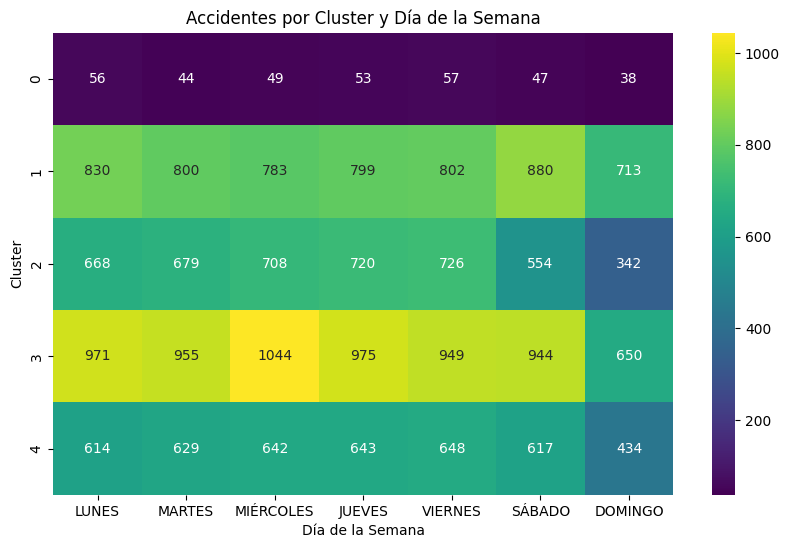

In [140]:
# Create a cross-tabulation of cluster and DIA_SEMANA
cluster_day_counts = pd.crosstab(data_grav['cluster'], data_grav['DIA_NOMBRE'])

# Convert DIA_SEMANA to uppercase and reorder days of the week
days_order = ['LUNES', 'MARTES', 'MIÉRCOLES', 'JUEVES', 'VIERNES', 'SÁBADO', 'DOMINGO']
cluster_day_counts = cluster_day_counts.rename(columns=lambda x: x.upper()).reindex(columns=days_order)


# Plot the cross-tabulation as a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_day_counts, annot=True, cmap='viridis', fmt="d")
plt.title('Accidentes por Cluster y Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Cluster')
plt.show()


En este gráfico se detalla la distribución de los accidentes por cluster en los días de la semana.

Se puede ver que en el cluster 0, 2 y 4 ocurren más accidentes los viernes.

Que en el cluster 3 ocurren más accidentes los miércoles.

Que en el cluster 1 ocurren más accidentes los sábado.

En términos generales, los fines de semana son los días en los que ocurren menos accidentes, con la excepción del cluster 1.

Aún así, en todos los clusters el domingo es el día con menos accidentes.

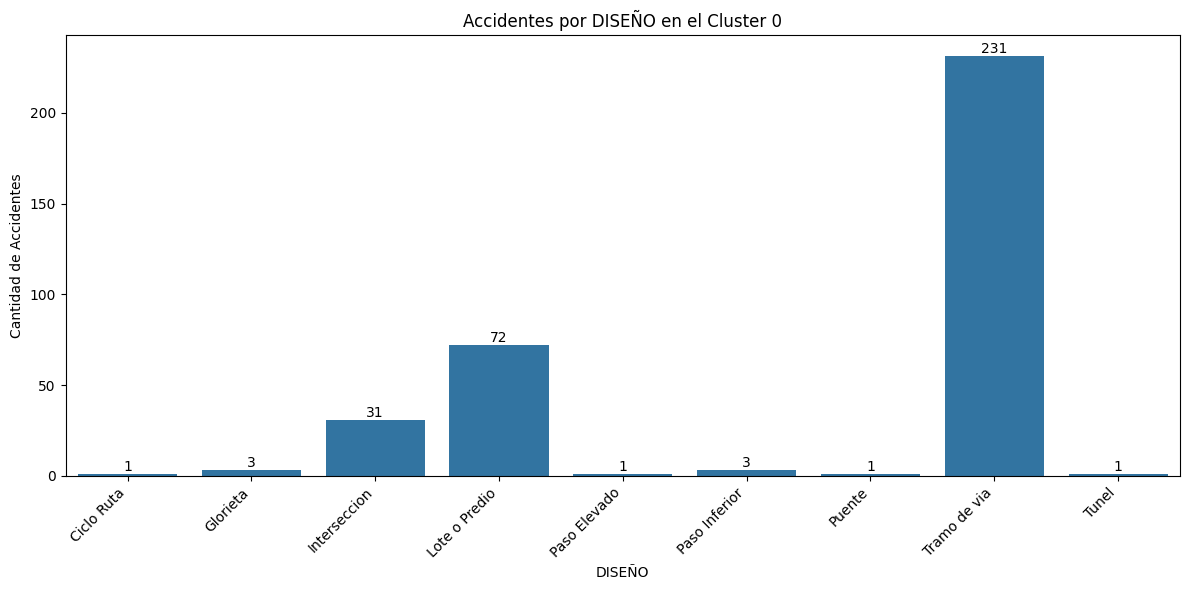

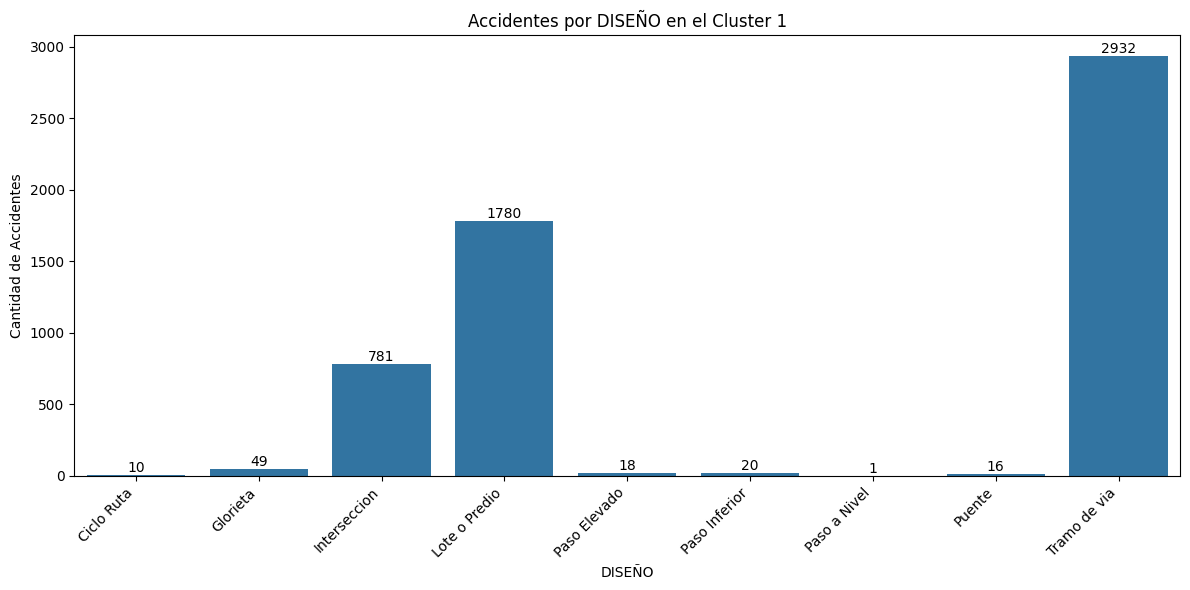

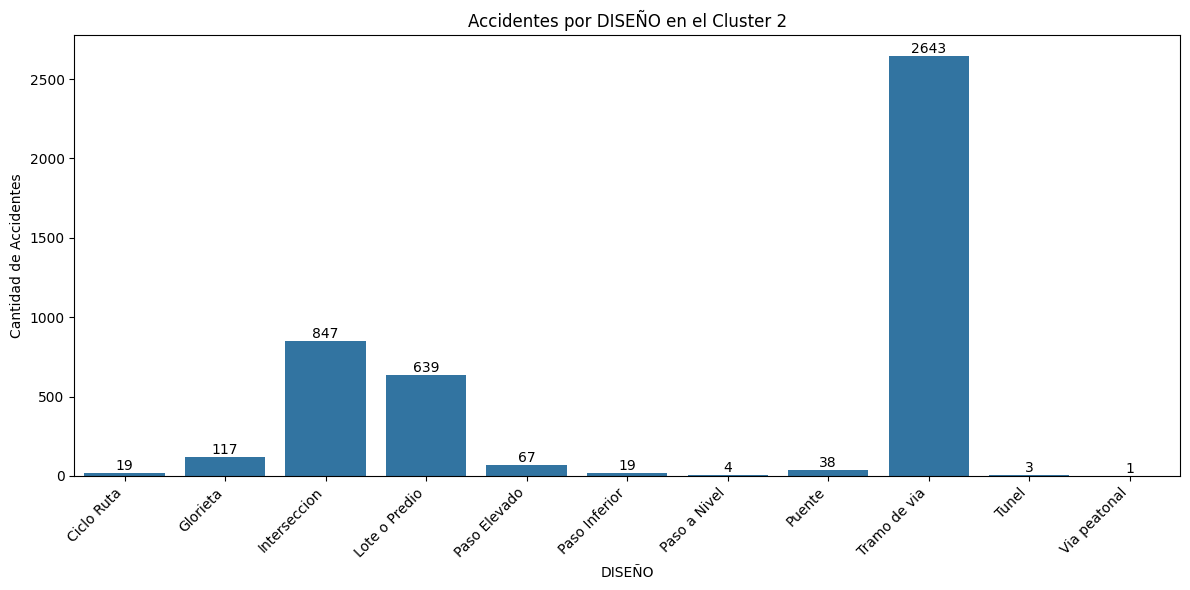

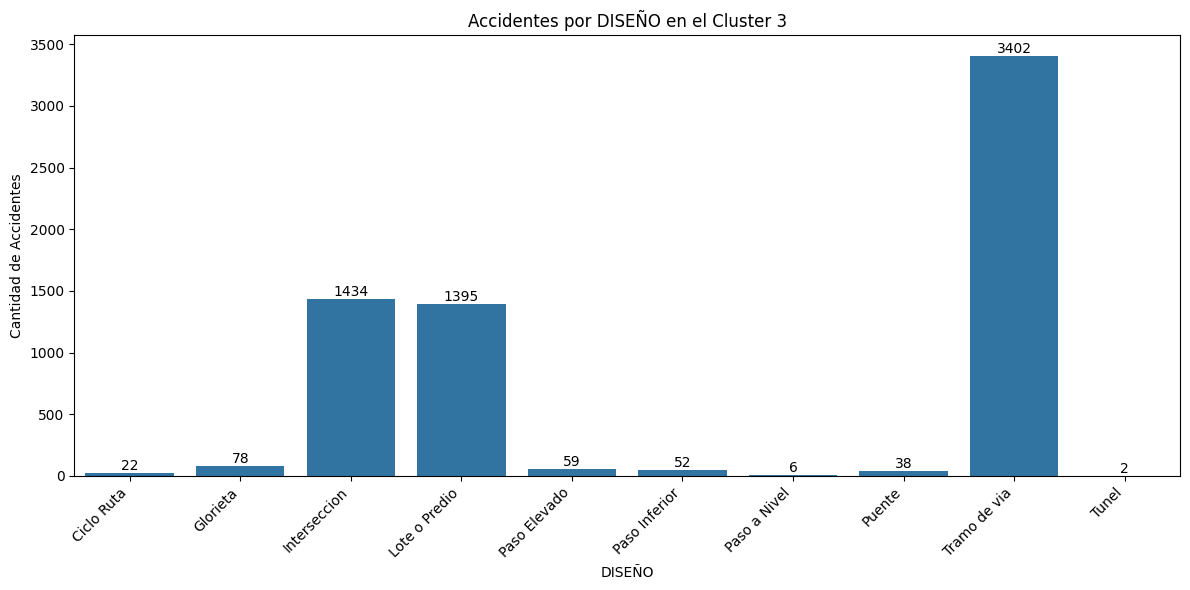

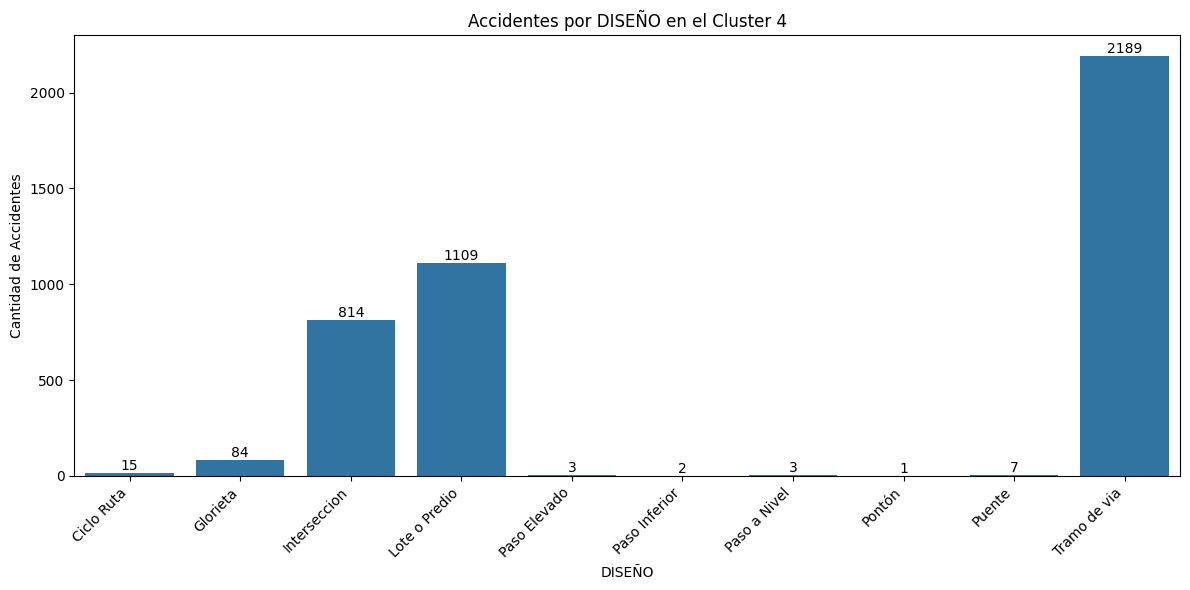

In [141]:
# Agrupar los datos por cluster y DISENO, contando la cantidad de accidentes en cada grupo
cluster_diseno_counts = data_grav.groupby(['cluster', 'DISENO'])['GRAVEDAD'].count().reset_index()

# Crear un gráfico para cada cluster
for cluster_id in cluster_diseno_counts['cluster'].unique():
  cluster_data = cluster_diseno_counts[cluster_diseno_counts['cluster'] == cluster_id]
  plt.figure(figsize=(12, 6))
  ax = sns.barplot(x='DISENO', y='GRAVEDAD', data=cluster_data)

  # Agregar las cantidades encima de cada barra
  for p in ax.patches:
      ax.annotate(f'{int(p.get_height())}',
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='bottom')

  plt.title(f'Accidentes por DISEÑO en el Cluster {cluster_id}')
  plt.xlabel('DISEÑO')
  plt.ylabel('Cantidad de Accidentes')
  plt.xticks(rotation=45, ha='right')
  plt.tight_layout()
  plt.show()


Esta gráfica muestra el tipo de infraestructura en la que ocurren los accidentes en cada cluster.

En todos los cluster destacan 3 tipos de infraestructura:

*   Tramo de vía.
*   lote o predio.
*   Intersección.

En cada cluster los tramos de vía son las zonas en las que más ocurren accidentes, con 231 en el cluster 0, 2932 en el cluster 1, 2643 en el cluster 2, 3402 en el cluster 3 y 2189 en el cluster 4.

En los cluster 2 y 3, las intersecciones son las zonas con la segunda mayor cantidad de accidentes, 847 y 1434 respectivamente.

En los cluster 0, 1 y 4, el segundo lugar es ocupado por los lotes o predios, con 72, 1780 y 1109 accidentes respectivamente.

En conjunto, 11397 accidentes ocurren en tramos de vía, 4995 en lotes o predios y 3907 en intersecciones.


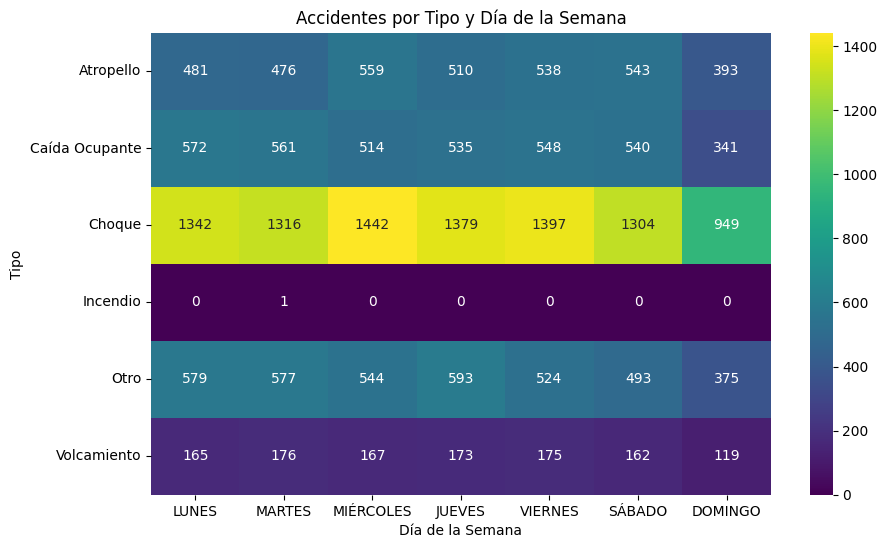

In [153]:

import matplotlib.pyplot as plt
import seaborn as sns

# Create a cross-tabulation of cluster and DIA_NOMBRE (Day of the week)
cluster_day_counts = pd.crosstab(data_grav['CLASE'], data_grav['DIA_NOMBRE'])

# Convert DIA_NOMBRE to uppercase and reorder days of the week
days_order = ['LUNES', 'MARTES', 'MIÉRCOLES', 'JUEVES', 'VIERNES', 'SÁBADO', 'DOMINGO']
cluster_day_counts = cluster_day_counts.rename(columns=lambda x: x.upper()).reindex(columns=days_order)

# Plot the cross-tabulation as a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_day_counts, annot=True, cmap='viridis', fmt="d")
plt.title('Accidentes por Tipo y Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Tipo')
plt.show()


Esta gráfica muestra la distribución de cada tipo de accidente durante los días de la semana, todos los días el accidente más común es el choque, el jueves es el día en que ocurren más atropellos, los lunes son los días en que ocurren más caídas de ocupantes, el jueves es el día en que ocurren más choques, el jueves es el día en que ocurren más accidentes catalogados como otro, el jueves es el día en que ocurren más volcamientos y el martes es el único día que ocurrió un incendio.

De todos los días, el jueves presentó la cifra máxima de accidentes en cuatro de las seis categorías.

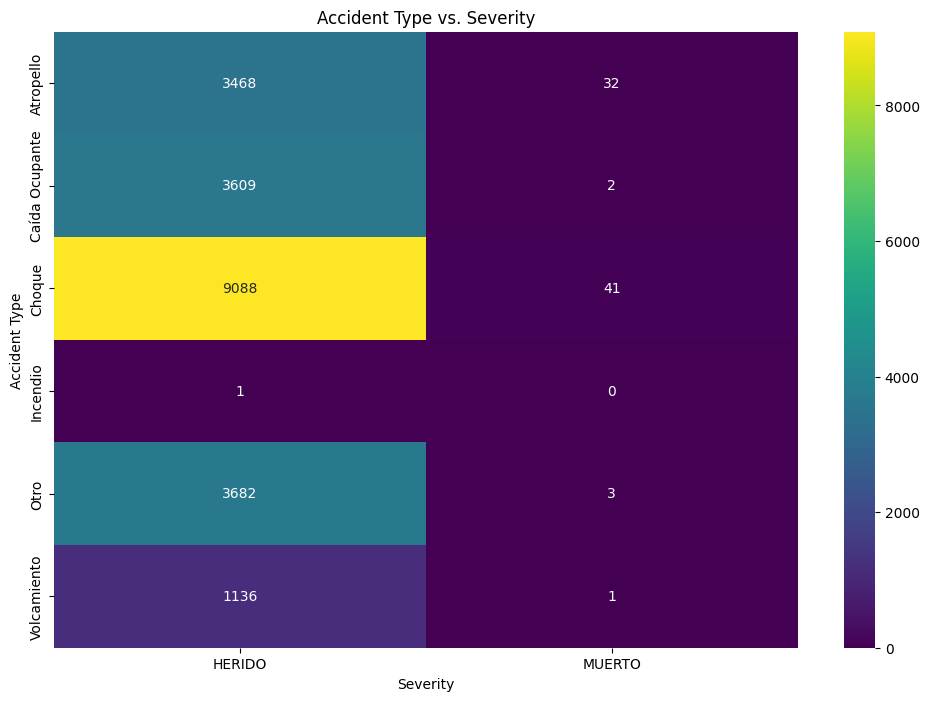

In [157]:

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'data_grav' is your DataFrame containing the accident data
# and it has columns like 'cluster', 'CLASE', and 'GRAVEDAD'

# Create a cross-tabulation of accident type and severity
accident_severity_counts = pd.crosstab(data_grav['CLASE'], data_grav['GRAVEDAD'])

# Plot the cross-tabulation as a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(accident_severity_counts, annot=True, cmap='viridis', fmt="d")
plt.title('Accident Type vs. Severity')
plt.xlabel('Severity')
plt.ylabel('Accident Type')
plt.show()


Esta gráfica compara los tipos de accidentes con la gravedad de este, el choque es el tipo de accidente que deja más heridos y causa más muertes (9088 y 41) , el incendio solo deja heridos, los atropellos dejan 3468 heridos y 32 muestes, las caídas de ocupante 3609 heridos y 2 muertes, los volcamientos 1136 heridos y 1 muerte, y los catalogados como otro dejan 3682 heridos y muertes.

# Hallazgos

Tras llevar a cabo un análisis exhaustivo de la información en la base de datos, se descubrió lo siguiente:

*   Los días en que ocurren más accidentes son los miércoles, jueves y viernes.
*   En el cluster 1, a diferencia de los demás cluster, la mayor cantidad de accidentes ocurren los sábado.
*   Los días en que ocurren menos accidentes son los domingos.
*   Accidentes mortales: En el cluster 0 hay 3, en el cluster 1 hay 16, en el cluster 2 hay 14, en el cluster 3 hay 32 y en el cluster 4 hay 14.
*   Tipo de accidente vs muertes: Los volcamientos 1 muerte, otro 3 muertes, los choques 41 muertes, las caídas de ocupante 2 muertes y los atropellos 32 muertes.
*   Tipo de accidente vs heridos: Los volcamientos 1136 heridos, otro 3682 heridos, incendios 1 herido, choque 9088 heridos, caída ocupante 3609 y atropello 3468 heridos.
*   Los tipos de accidentes más comunes son los choques y otros.
*   Los jueves son el día en que ocurren más atropellos, choques, volcamientos y otros.
*   El martes es el único día en que ocurre un incendio.
*   El lunes es el día en que ocurren más caídas de ocupantes.
*   La mayoría de los accidentes ocurren de 6 a 8 de la mañana y de 4 a 7 de la tarde.
*  A partir de las 11 de la noche y hasta las 5 de la mañana, la cantidad de accidentes se reducen considerablemente en todos los cluster.
*   Las comunas en las que ocurren más accidentes son Aranjuez, Castilla, Corregimiento de San Antonio de Prado, La Candelaria, Laureles Estadio y Robledo.
*   Los barrios en que ocurren más accidentes son Cabecera San Antonio de Prado, Castilla, Campo Amor, La Candelaria y Los Colores.
*   La mayoría de accidentes ocurren en tramos de vía, lotes o predios e intersecciones.


In [142]:
import joblib # Esta librería sirve para guardar y llamar objetos de Python, como los modelos de machine learning
joblib.dump(kmeans, 'kmeans_model.pkl') # Se guarda el modelo de kmeans en el objeto 'kmeans_model.pkl'
joblib.dump(scaler, 'scaler.pkl') # Se guardan los parametros con los que se estandarizaron los datos con los que se entreno el modelo de kmeans

['scaler.pkl']

# Informe ejecutivo de resultados

Se espera que informe:

Dónde ubicar:

*   los agentes de tránsito
*   las ambulancias

Los horarios y el personal qué debe estar disponible para atender los eventos.
Teniendo en cuenta en qué horarios, días y fechas particulares se presentan mayor accidentalidad y de qué tipo.

Recomendaciones para prevenir los accidentes de tránsito.

# Agentes de tránsito

Se recomienda ubicar agentes de tránsito en las intersecciones y en los tramos de vía particularmente en las comunas de castilla, el poblado, la candelaria, robledo, belén, aranjuez, guayabal y laureles estadio.

Los días y horarios que se debem priorizar son los martes, miércoles y jueves de 6 a 8 de la mañana y de 4 a 7 de la tarde.

En particular, los jueves se presenta la mayor accidentabilidad en atropellos, choques, volcamientos y otros.

Se recomendaría utilizar 1000 agentes de tránsito que roten durante los días y los distintos horarios de actividad para asegurar que desarrollen su labor de la mejor manera.

Para asegurar la eficiencia del trabajo, se recomienda disminuir la cantidad de agentes en servicio desde las 11 de la noche hasta las 5 de la mañana debido a la baja accidentalidad de el periodo.

Dado que el tipo de accidente que más ocurre son los choques y la zona en la que más accidentes ocurren son los tramos de vía, recomendaría considerar la posibilidad de mantener agentes de tránsito en estas zonas durante las 24 horas del día.

# Ambulancias

Se recomienda ubicar ambulancias en los cinco centroides, una en el centroide del cluster 0 y un mínimo de dos ambulancias por centroide en los demás cluster.

Las ambulancias deberían estar disponibles las 24 horas del día todos los días, para lograrlo se recomienda subcontratar servicios de ambulancias privadas que sean distribuidas en los cinco cluster.

A partir de las 11 de la noche y hasta las 5 de la mañana se podría reducir la cantidad de ambulancias en circulación a 1 por cluster.

Debido a la baja cantidad de accidentes fatales se recomienda usar cinco ambulancias que recorran todos los cluster confirmando que los accidentes sean realmente fatales.

Se recomienda que las ambulancias estén equipadas para lidiar con volcamientos, choques, caídas de ocupantes y atropellos, especialmente los miércoles, jueves y viernes.